In [120]:
import numpy as np                                                                # use  for numerical operations
import pandas as pd                                                               # use for creating DataFrames
import matplotlib.pyplot as plt                                                   # use for basic visualizations
import seaborn as sns                                                             # use for basic visualizations
import plotly.graph_objects as go                                                 # use for interactive visualizations
import plotly.express as px
from sklearn.model_selection import train_test_split, KFold, cross_val_score      # splits dataset into training and testing parts and used for cross-validation by splitting the dataset into multiple folds
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle



# nlp library 
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer

In [121]:
# Set pandas to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Optional: to avoid line wrapping
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [122]:
df_Emergency = pd.read_csv("../data/emergency_traige.csv", sep=";", encoding="ISO-8859-1")


In [123]:
df_Emergency.shape

(1267, 24)

In [124]:
#df_Emergency["mistriage"].head()
#df_Emergency.to_csv("emergency_traige1.csv", index=False)
df_Emergency.head()

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,SBP,DBP,HR,RR,BT,Saturation,KTAS_RN,Diagnosis in ED,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min,mistriage
0,2,2,71,3,3,2,right ocular pain,1,1,2,160,100,84,18,36.6,100,2,Corneal abrasion,1,4,2,86,"5,00",1
1,1,1,56,12,3,2,right forearm burn,1,1,2,137,75,60,20,36.5,NaN,4,"Burn of hand, firts degree dorsum",1,5,4,64,"3,95",1
2,2,1,68,8,2,2,"arm pain, Lt",1,1,2,130,80,102,20,36.6,98,4,"Fracture of surgical neck of humerus, closed",2,5,4,862,"1,00",1
3,1,2,71,8,1,1,ascites tapping,1,1,3,139,94,88,20,36.5,NaN,4,Alcoholic liver cirrhosis with ascites,1,5,6,108,"9,83",1
4,1,2,58,4,3,1,"distension, abd",1,1,3,91,67,93,18,36.5,NaN,4,Ascites,1,5,8,109,"6,60",1


In [125]:
df_Emergency = df_Emergency.drop(columns=["mistriage"])

In [126]:
df_Emergency.shape

(1267, 23)

In [127]:
#df_Emergency1 = pd.read_csv("synthetic_data_updated_1.csv")

In [128]:
#df_Emergency1.shape

In [129]:
#df_Emergency_join = pd.concat([df_Emergency, df_Emergency1], axis=0, ignore_index=True)
df_Emergency_join = df_Emergency

In [130]:
df_Emergency_join.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1267 entries, 0 to 1266
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Group                     1267 non-null   int64 
 1   Sex                       1267 non-null   int64 
 2   Age                       1267 non-null   int64 
 3   Patients number per hour  1267 non-null   int64 
 4   Arrival mode              1267 non-null   int64 
 5   Injury                    1267 non-null   int64 
 6   Chief_complain            1267 non-null   object
 7   Mental                    1267 non-null   int64 
 8   Pain                      1267 non-null   int64 
 9   NRS_pain                  1267 non-null   object
 10  SBP                       1267 non-null   object
 11  DBP                       1267 non-null   object
 12  HR                        1267 non-null   object
 13  RR                        1267 non-null   object
 14  BT                      

In [131]:
df_Emergency_join["KTAS_expert"].value_counts()

KTAS_expert
3    487
4    459
2    220
5     75
1     26
Name: count, dtype: int64

In [132]:
df_Emergency_join["Chief_complain"]

0                           right ocular pain
1                          right forearm burn
2                                arm pain, Lt
3                             ascites tapping
4                             distension, abd
5                                       fever
6                       With chest discomfort
7                                 pain, chest
8                         LBP - Low back pain
9                              Eczema, Eyelid
10                      acute epigastric pain
11                                  pain, leg
12                            epigastric pain
13                                   abd pain
14                                   headache
15                                   headache
16                                         ??
17                                 Open Wound
18                                   RUQ pain
19                          Gingival swelling
20                                  chin pain
21                              Fi

In [133]:
df_Emergency_join.shape

(1267, 23)

###  data cleaning

In [134]:
df_Emergency_join.isnull().sum()  # checking the null values

Group                         0
Sex                           0
Age                           0
Patients number per hour      0
Arrival mode                  0
Injury                        0
Chief_complain                0
Mental                        0
Pain                          0
NRS_pain                      0
SBP                           0
DBP                           0
HR                            0
RR                            0
BT                            0
Saturation                  688
KTAS_RN                       0
Diagnosis in ED               2
Disposition                   0
KTAS_expert                   0
Error_group                   0
Length of stay_min            0
KTAS duration_min             0
dtype: int64

In [135]:
df_Emergency_join.describe() 

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Mental,Pain,KTAS_RN,Disposition,KTAS_expert,Error_group,Length of stay_min
count,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000
mean,1.456985,1.521705,54.423836,7.519337,2.820837,1.192581,1.105762,0.563536,3.335438,1.609313,3.265983,0.558011,11016.102605
std,0.498343,0.499726,19.725033,3.160563,0.807904,0.394482,0.447768,0.496143,0.885391,1.157983,0.885803,1.571489,80446.092065
min,1.000000,1.000000,16.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,1.000000,37.000000,5.000000,2.000000,1.000000,1.000000,0.000000,3.000000,1.000000,3.000000,0.000000,133.000000
50%,1.000000,2.000000,57.000000,7.000000,3.000000,1.000000,1.000000,1.000000,3.000000,1.000000,3.000000,0.000000,274.000000
75%,2.000000,2.000000,71.000000,10.000000,3.000000,1.000000,1.000000,1.000000,4.000000,2.000000,4.000000,0.000000,606.500000
max,2.000000,2.000000,96.000000,17.000000,7.000000,2.000000,4.000000,1.000000,5.000000,7.000000,5.000000,9.000000,709510.000000


In [136]:
# first we check the  % age of nan value present in each features

In [137]:
feature_with_null_values = [feature for feature in df_Emergency_join.columns if df_Emergency[feature].isnull().sum()>1]
feature_with_null_values

['Saturation', 'Diagnosis in ED']

In [138]:
# here we print the percentage of null values
for feature in feature_with_null_values:
    print(feature, np.round(df_Emergency_join[feature].isnull().mean(),2),"% missing values")

Saturation 0.54 % missing values
Diagnosis in ED 0.0 % missing values


In [139]:
for feature in feature_with_null_values:
    print(feature, np.round(df_Emergency_join[feature].isnull().sum(),2)," missing values")

Saturation 688  missing values
Diagnosis in ED 2  missing values


In [140]:
df_Emergency_join.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1267 entries, 0 to 1266
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Group                     1267 non-null   int64 
 1   Sex                       1267 non-null   int64 
 2   Age                       1267 non-null   int64 
 3   Patients number per hour  1267 non-null   int64 
 4   Arrival mode              1267 non-null   int64 
 5   Injury                    1267 non-null   int64 
 6   Chief_complain            1267 non-null   object
 7   Mental                    1267 non-null   int64 
 8   Pain                      1267 non-null   int64 
 9   NRS_pain                  1267 non-null   object
 10  SBP                       1267 non-null   object
 11  DBP                       1267 non-null   object
 12  HR                        1267 non-null   object
 13  RR                        1267 non-null   object
 14  BT                      

In [141]:
df_Emergency_join['NRS_pain'].value_counts()['#BOÞ!']  # Here some of the #bop! values which is wrong value we consider these values as null values

np.int64(556)

In [142]:
df_Emergency_join['SBP'].value_counts()["??"]  # # Here some of the ?? values which is wrong value we consider these values as null values
#df_Emergency['SBP'].unique()

np.int64(25)

In [143]:
df_Emergency_join['SBP'].unique() #  ?? missing value

array(['160', '137', '130', '139', '91', '140', '110', '169', '148',
       '141', '120', '121', '135', '100', '133', '124', '118', '80',
       '180', '125', '162', '116', '152', '164', '196', '144', '150',
       '200', '113', '119', '156', '165', '132', '??', '199', '138',
       '176', '170', '136', '194', '122', '214', '178', '108', '50',
       '145', '142', '210', '143', '65', '129', '123', '158', '187', '96',
       '70', '102', '161', '90', '105', '190', '151', '134', '106', '149',
       '189', '197', '155', '131', '168', '166', '126', '115', '128',
       '114', '153', '117', '101', '159', '109', '157', '182', '111',
       '163', '167', '127', '147', '154', '112', '179', '191', '93', '98',
       '198', '204', '177', '195', '107', '171', '183', '146', '95',
       '202', '174', '86', '94', '181', '75', '211', '173', '193', '205',
       '99', '275', '201', '103', '203', '104', '79', '60', '221', '233',
       '206', '97', '220', '186', '213'], dtype=object)

In [144]:
df_Emergency_join['DBP'].value_counts()["??"] #  ?? missing value 

np.int64(29)

In [145]:
df_Emergency_join['HR'].value_counts()["??"] #  ?? missing value 

np.int64(20)

In [146]:
df_Emergency_join['RR'].value_counts()["??"]#  ?? missing value 

np.int64(22)

In [147]:
df_Emergency_join['BT'].value_counts()["??"] #  ?? missing value 

np.int64(18)

In [148]:
df_Emergency_join['KTAS duration_min'].unique()  # Here value is in str and str to float we can do but here is not dot value here comma so we need to replace with dot first

array(['5,00', '3,95', '1,00', '9,83', '6,60', '2,00', '3,00', '10,23',
       '3,23', '4,00', '7,53', '7,15', '8,00', '9,88', '10,53', '12,45',
       '9,48', '5,50', '8,78', '8,17', '5,30', '7,42', '12,48', '8,10',
       '3,82', '14,60', '6,87', '17,07', '13,43', '6,57', '6,00', '4,82',
       '4,15', '3,93', '10,40', '5,32', '4,07', '5,85', '4,12', '9,05',
       '10,18', '4,97', '6,65', '9,08', '11,17', '5,02', '4,13', '2,85',
       '6,77', '15,13', '5,63', '12,05', '4,87', '14,07', '7,02', '12,17',
       '3,53', '6,58', '7,00', '5,33', '3,58', '8,15', '8,60', '8,13',
       '4,10', '6,40', '9,00', '10,00', '11,38', '5,58', '3,60', '9,58',
       '6,08', '11,03', '4,88', '16,38', '8,02', '13,90', '9,35', '4,32',
       '5,88', '13,15', '4,42', '6,63', '9,67', '9,65', '8,92', '2,78',
       '6,48', '5,10', '14,52', '3,22', '8,38', '13,92', '9,27', '3,43',
       '2,98', '7,82', '5,27', '9,07', '4,18', '5,70', '9,22', '10,05',
       '3,40', '3,32', '7,87', '10,70', '13,77', '11,9

In [149]:
df_Emergency_join['KTAS duration_min'] = df_Emergency_join['KTAS duration_min'].astype(str).str.replace(",",'.')  # Here , replace with dot(.)
df_Emergency_join['KTAS duration_min']= df_Emergency_join['KTAS duration_min'].astype(float)    # Here datatype convert into float

In [150]:
df_Emergency_join['KTAS duration_min'].isnull().sum()
df_Emergency_join['KTAS duration_min'].dtype
#df_Emergency['KTAS duration_min']

dtype('float64')

In [151]:


health = ['SBP', 'DBP', 'HR', 'RR', 'BT']

for feature in health:
    df_Emergency_join[feature] = df_Emergency_join[feature].replace("??", np.nan)   # Here ?? value replace with nan value 
    df_Emergency_join[feature] = pd.to_numeric(df_Emergency_join[feature], errors='coerce') # convert datatype string to float
    print(f"{feature} : {df_Emergency_join[feature].dtype}")  # chck the value of type

    

SBP : float64
DBP : float64
HR : float64
RR : float64
BT : float64


In [152]:
df_Emergency_join["Saturation"].unique()  # Here ?? value which is 9 value add in missing values

array(['100', nan, '98', '97', '95', '99', '96', '78', '68', '88', '89',
       '92', '94', '??', '90', '93', '91', '76', '85', '86', '80', '20',
       '74'], dtype=object)

In [153]:
df_Emergency_join['Saturation'].value_counts()['??']
df_Emergency_join['Saturation'] = df_Emergency_join['Saturation'].replace("??", np.nan)

In [154]:
df_Emergency_join["Saturation"].isnull().sum()

np.int64(697)

In [155]:
df_Emergency_join.isnull().sum()

Group                         0
Sex                           0
Age                           0
Patients number per hour      0
Arrival mode                  0
Injury                        0
Chief_complain                0
Mental                        0
Pain                          0
NRS_pain                      0
SBP                          25
DBP                          29
HR                           20
RR                           22
BT                           18
Saturation                  697
KTAS_RN                       0
Diagnosis in ED               2
Disposition                   0
KTAS_expert                   0
Error_group                   0
Length of stay_min            0
KTAS duration_min             0
dtype: int64

In [156]:
df_Emergency_join["NRS_pain"] = df_Emergency_join["NRS_pain"].replace("#BOÞ!",np.nan)
df_Emergency_join["NRS_pain"].isnull().sum()

np.int64(556)

In [157]:
#sns.displot(df_Emergency_join["NRS_pain"], kde=True)
#df_Emergency_join["NRS_pain"] = pd.to_numeric(df_Emergency_join["NRS_pain"], errors='coerce')

In [158]:
df_Emergency_join.isnull().sum()           # 8 feature have missing value 

Group                         0
Sex                           0
Age                           0
Patients number per hour      0
Arrival mode                  0
Injury                        0
Chief_complain                0
Mental                        0
Pain                          0
NRS_pain                    556
SBP                          25
DBP                          29
HR                           20
RR                           22
BT                           18
Saturation                  697
KTAS_RN                       0
Diagnosis in ED               2
Disposition                   0
KTAS_expert                   0
Error_group                   0
Length of stay_min            0
KTAS duration_min             0
dtype: int64

In [159]:
feature_with_null_values = [feature for feature in df_Emergency_join.columns if df_Emergency_join[feature].isnull().sum()>1]  # checking the missing values
feature_with_null_values

['NRS_pain', 'SBP', 'DBP', 'HR', 'RR', 'BT', 'Saturation', 'Diagnosis in ED']

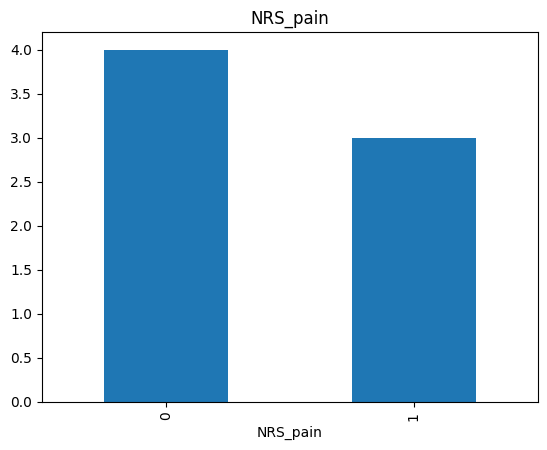

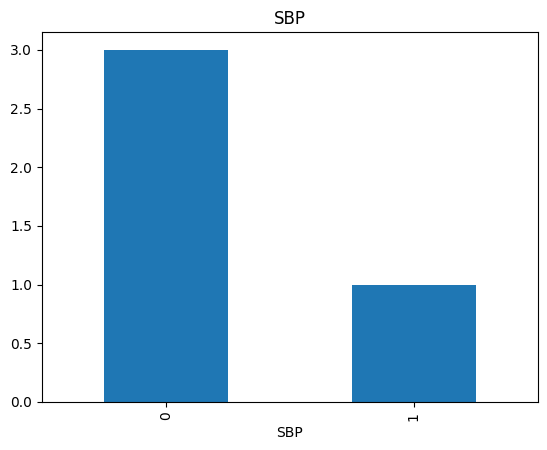

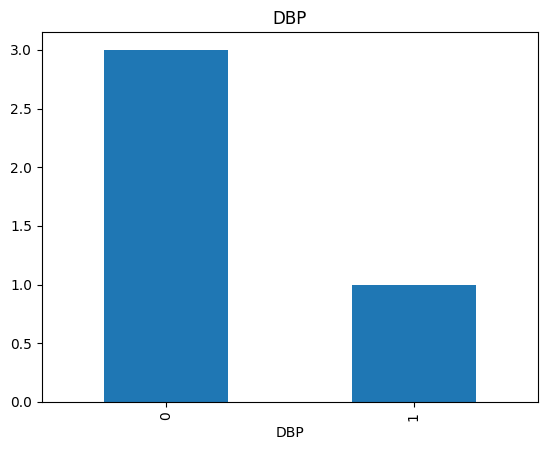

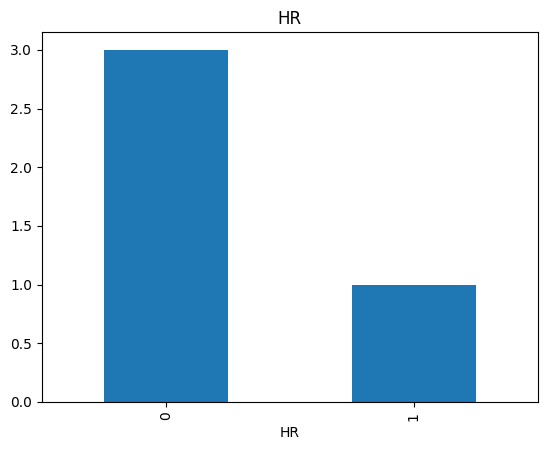

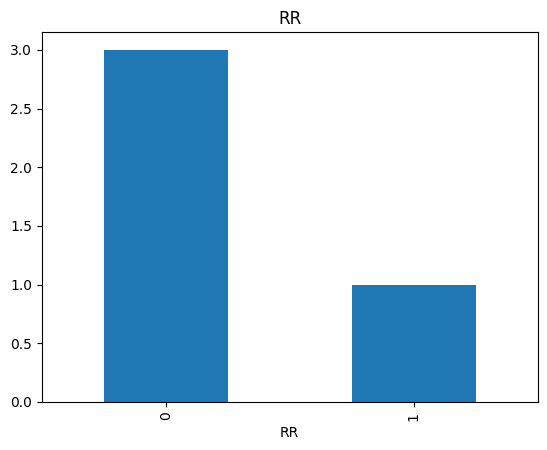

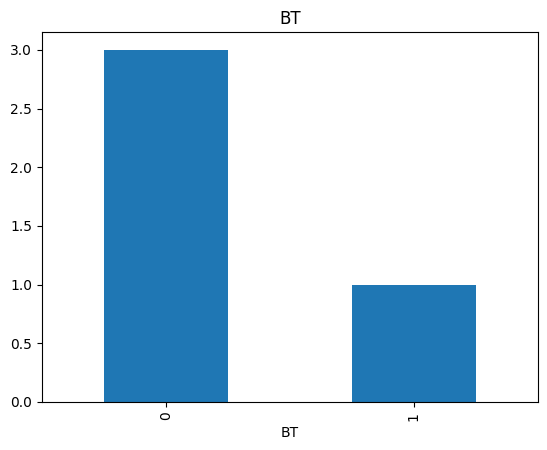

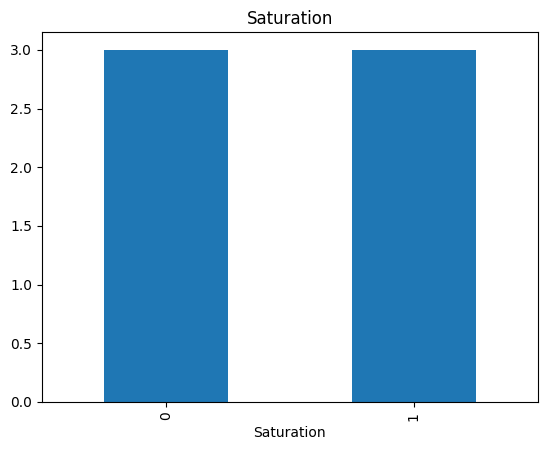

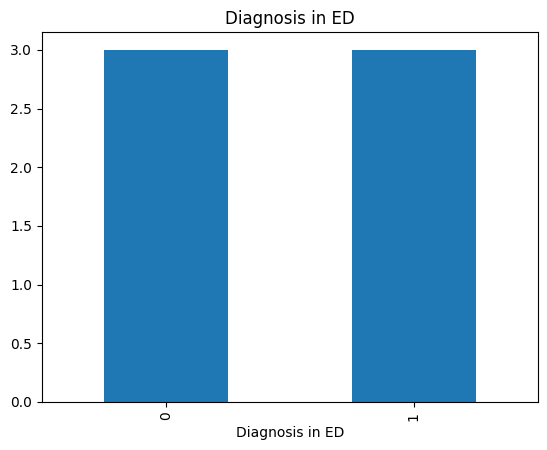

In [160]:
for features in feature_with_null_values:
    data = df_Emergency_join.copy()
    # let's create a variable indicate 1 if the value is missing or zero if the value is presenting
    data[features] = np.where(data[features].isnull(),1,0)
    # lets calculate the mean KTAS EXPERT  where the information is missing or information is present
    data.groupby(features)["KTAS_expert"].median().plot.bar()
    plt.title(features)
    plt.show()

In [161]:
df_Emergency_join["NRS_pain"] = df_Emergency_join["NRS_pain"].astype(float)
df_Emergency_join["NRS_pain"]= df_Emergency_join["NRS_pain"].fillna(df_Emergency_join["NRS_pain"].mean())   # nrs_pain distribution is look like normal so replace with mean


In [162]:
df_Emergency_join["NRS_pain"].isnull().sum()

np.int64(0)

In [163]:
df_Emergency_join['SBP'].unique()

array([160., 137., 130., 139.,  91., 140., 110., 169., 148., 141., 120.,
       121., 135., 100., 133., 124., 118.,  80., 180., 125., 162., 116.,
       152., 164., 196., 144., 150., 200., 113., 119., 156., 165., 132.,
        nan, 199., 138., 176., 170., 136., 194., 122., 214., 178., 108.,
        50., 145., 142., 210., 143.,  65., 129., 123., 158., 187.,  96.,
        70., 102., 161.,  90., 105., 190., 151., 134., 106., 149., 189.,
       197., 155., 131., 168., 166., 126., 115., 128., 114., 153., 117.,
       101., 159., 109., 157., 182., 111., 163., 167., 127., 147., 154.,
       112., 179., 191.,  93.,  98., 198., 204., 177., 195., 107., 171.,
       183., 146.,  95., 202., 174.,  86.,  94., 181.,  75., 211., 173.,
       193., 205.,  99., 275., 201., 103., 203., 104.,  79.,  60., 221.,
       233., 206.,  97., 220., 186., 213.])

## all the numerical variables

In [164]:
# list of all numerical feature
numeric_feature = [feature for feature in df_Emergency_join.columns if df_Emergency_join[feature].dtype !='O']  # make a varibale numerical feature using except dtypes object
numeric_feature

['Group',
 'Sex',
 'Age',
 'Patients number per hour',
 'Arrival mode',
 'Injury',
 'Mental',
 'Pain',
 'NRS_pain',
 'SBP',
 'DBP',
 'HR',
 'RR',
 'BT',
 'KTAS_RN',
 'Disposition',
 'KTAS_expert',
 'Error_group',
 'Length of stay_min',
 'KTAS duration_min']

In [165]:
len(numeric_feature)

20

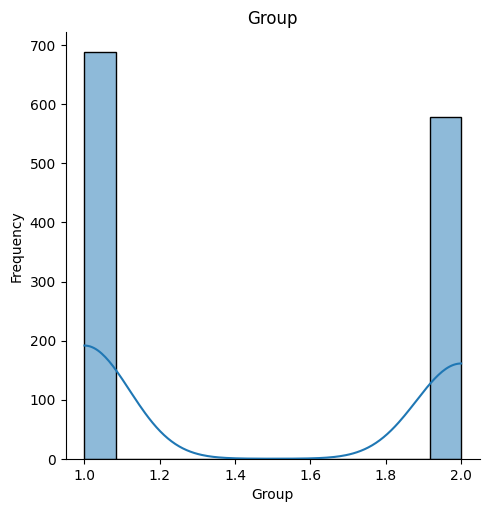

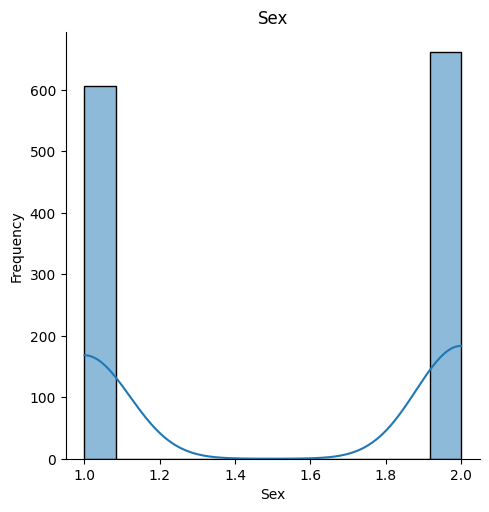

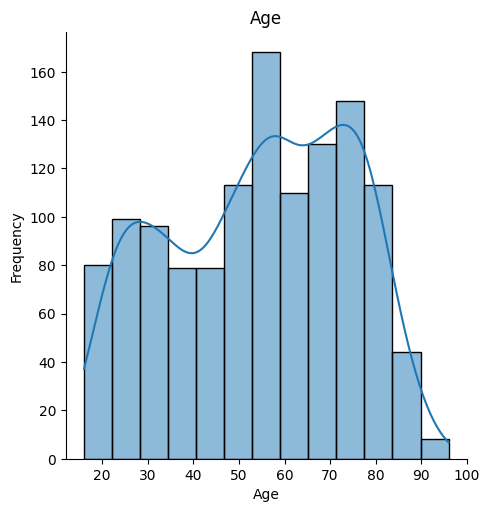

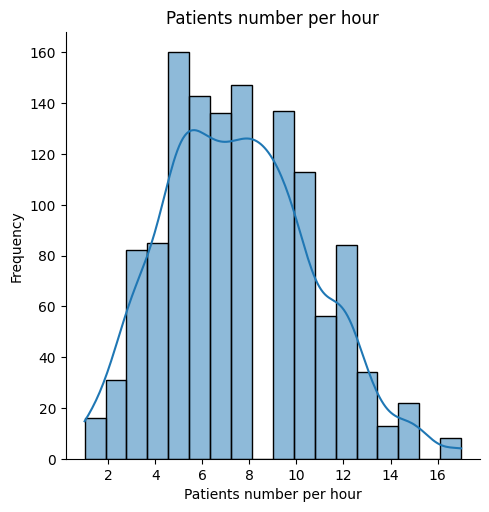

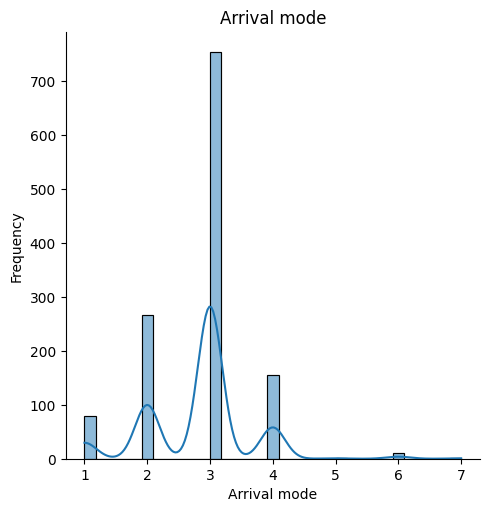

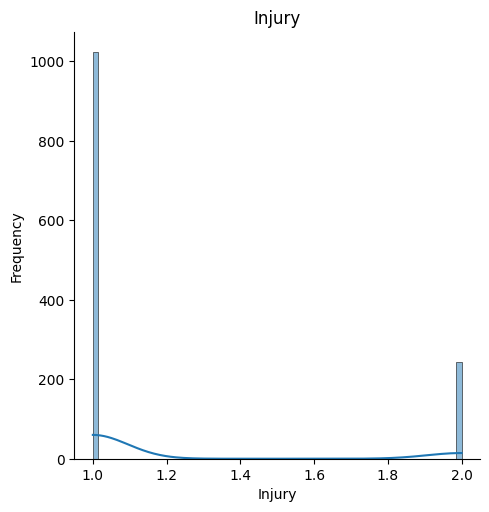

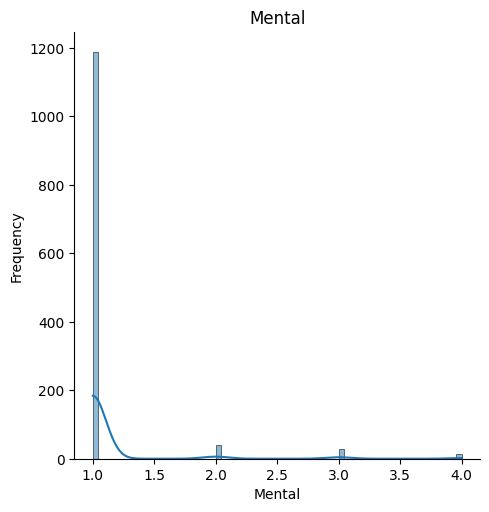

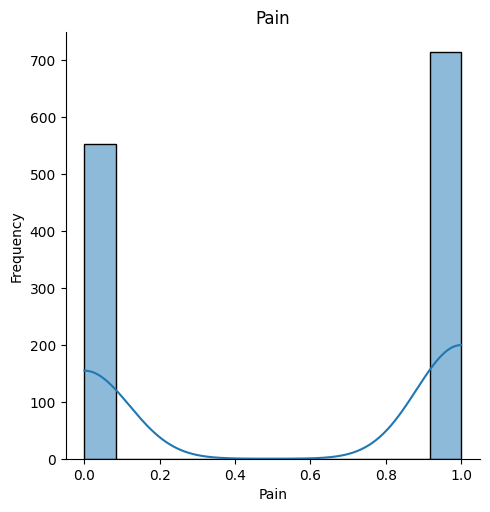

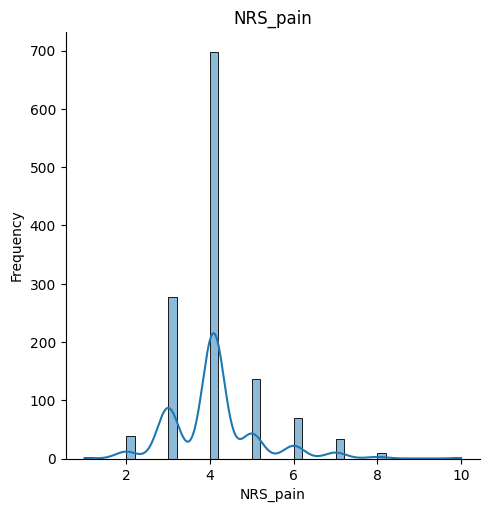

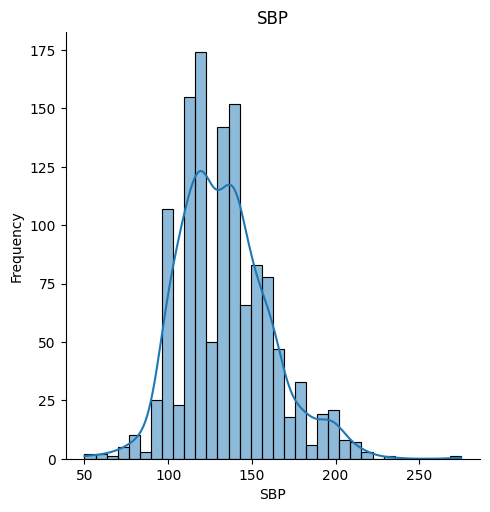

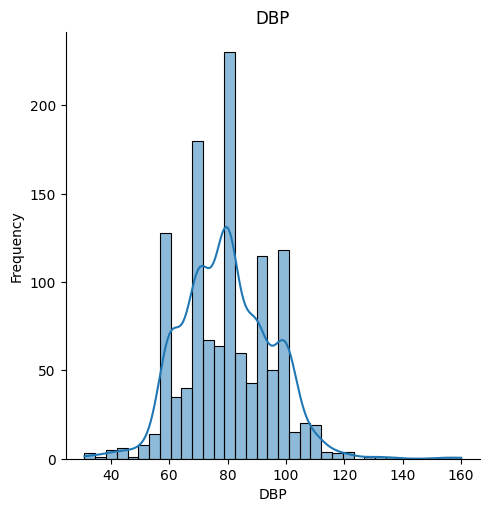

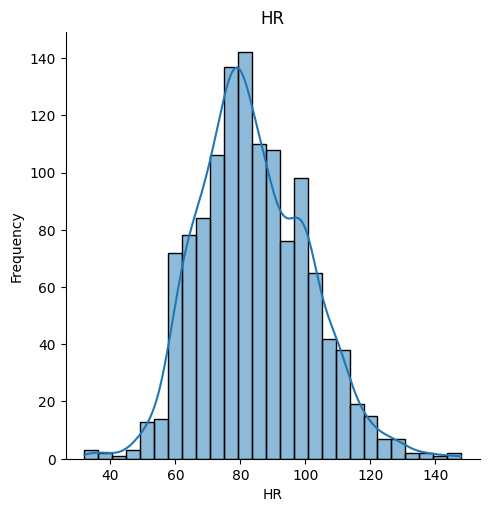

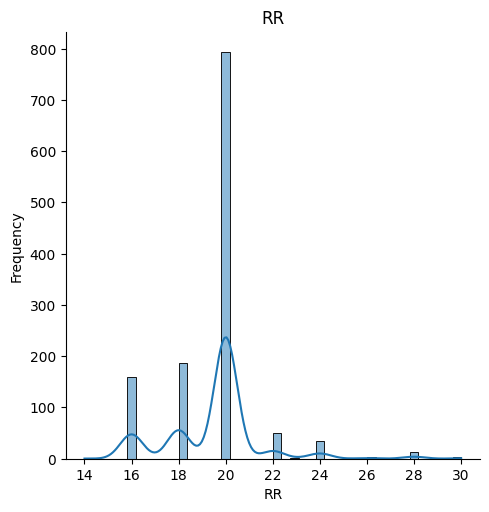

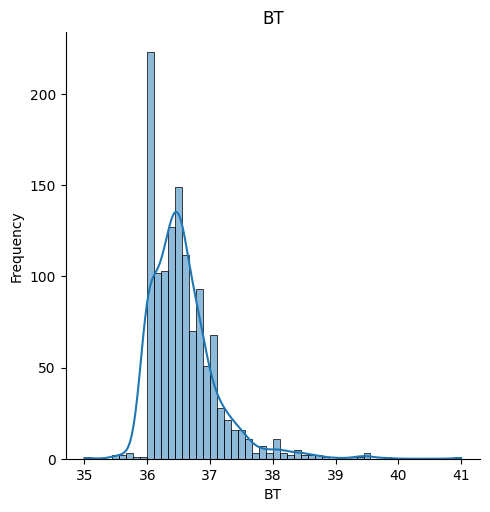

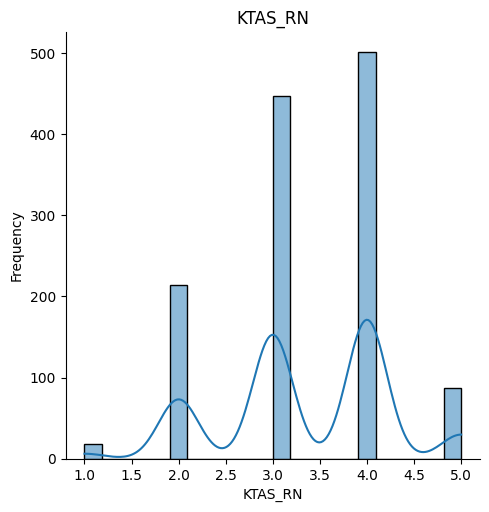

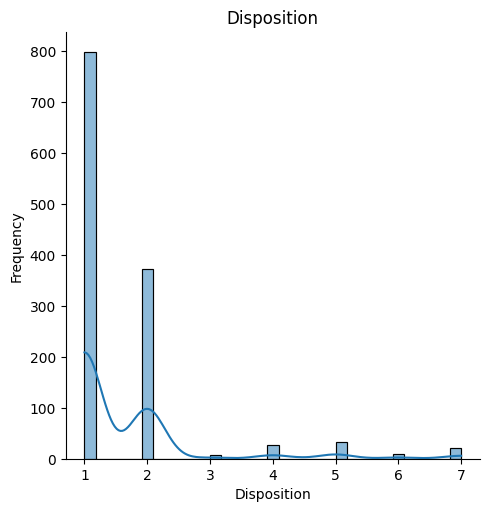

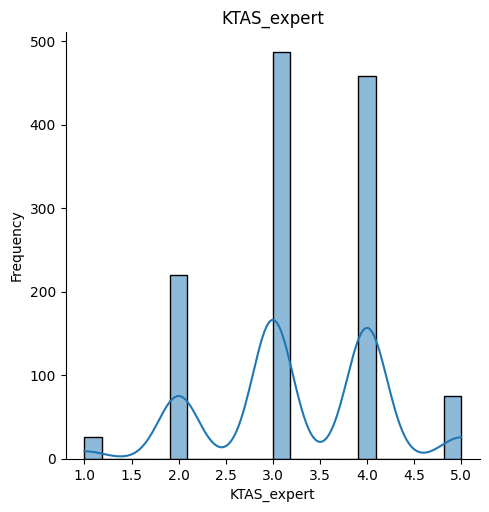

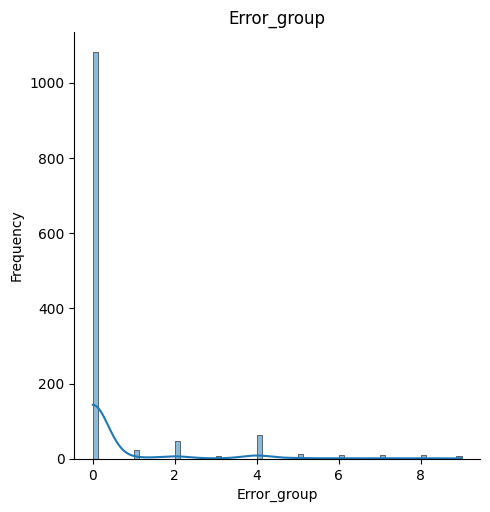

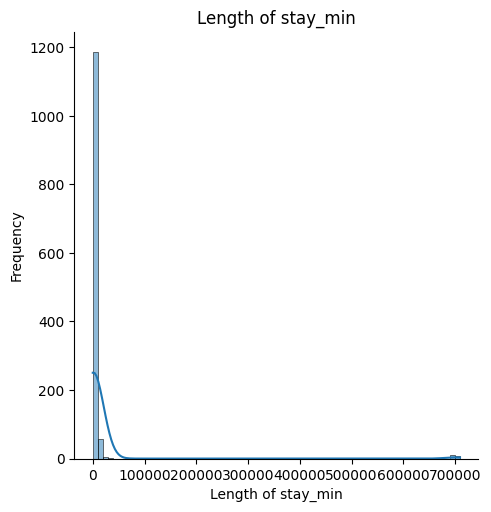

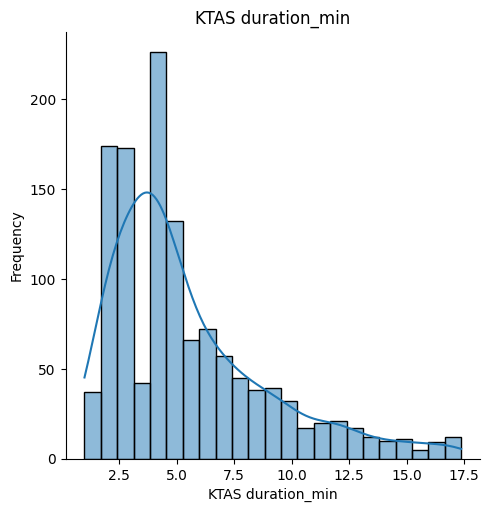

In [166]:
for feature in numeric_feature:    
    sns.displot(df_Emergency_join[feature], kde=True) # using a seaborn  each feature distribution 
    plt.title(f'{feature}')     # title for the graph
    plt.xlabel(feature)         # x axis label
    plt.ylabel('Frequency')     # y axis label
    plt.show()                  # show the graph

C:\Users\Khushal\AppData\Local\Temp\ipykernel_7304\4017179912.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_Emergency_join, x="KTAS_expert", y="NRS_pain", palette="muted", inner="box")


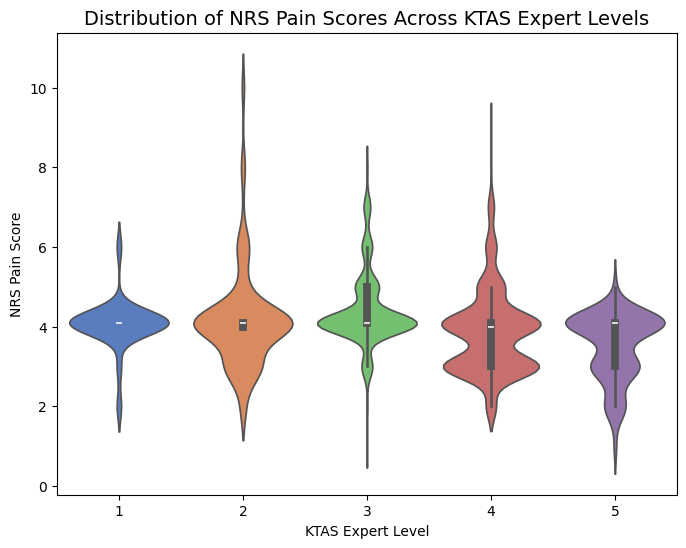

In [167]:

plt.figure(figsize=(8,6))
sns.violinplot(data=df_Emergency_join, x="KTAS_expert", y="NRS_pain", palette="muted", inner="box")
plt.title("Distribution of NRS Pain Scores Across KTAS Expert Levels", fontsize=14)
plt.xlabel("KTAS Expert Level")
plt.ylabel("NRS Pain Score")
plt.show()


violin plot shows that pain level is an important indicator of patient urgency higher pain scores are mostly seen in more severe triage levels but it is not the only factor determining the final KTAS expert classification.

In [168]:
df_Emergency_join["SBP"] =df_Emergency_join["SBP"].fillna(df_Emergency_join["SBP"].mean())  # Here SBP Feature graph look like normal we use mean

In [169]:
df_Emergency_join["DBP"] =df_Emergency_join["DBP"].fillna(float(df_Emergency_join["DBP"].mean())) # Here DBP Feature graph look like normal we use mean

df_Emergency_join["HR"] =df_Emergency_join["HR"].fillna(float(df_Emergency_join["HR"].mean())) # Here HR Feature graph look like normal we use mean
df_Emergency_join["RR"] =df_Emergency_join["RR"].fillna(float(20))   # here replace with highest class value because this is categorical feature
df_Emergency_join["BT"] =df_Emergency_join["BT"].fillna((df_Emergency_join["BT"].median()))  # right skewed distribution so replace with median

In [170]:
df_Emergency.isnull().sum() # now we have only 2 feature which has missing value

Group                         0
Sex                           0
Age                           0
Patients number per hour      0
Arrival mode                  0
Injury                        0
Chief_complain                0
Mental                        0
Pain                          0
NRS_pain                      0
SBP                           0
DBP                           0
HR                            0
RR                            0
BT                            0
Saturation                  697
KTAS_RN                       0
Diagnosis in ED               2
Disposition                   0
KTAS_expert                   0
Error_group                   0
Length of stay_min            0
KTAS duration_min             0
dtype: int64

## all the categorical variables

In [171]:
categorical_feature = [feature for feature in df_Emergency_join.columns if df_Emergency_join[feature].dtype =='O']   # check the no of object type
categorical_feature  

['Chief_complain', 'Saturation', 'Diagnosis in ED']

In [172]:
len(categorical_feature)

3

In [173]:
df_Emergency_join.head()

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Chief_complain,Mental,Pain,NRS_pain,SBP,DBP,HR,RR,BT,Saturation,KTAS_RN,Diagnosis in ED,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min
0,2,2,71,3,3,2,right ocular pain,1,1,2.0,160.0,100.0,84.0,18.0,36.6,100,2,Corneal abrasion,1,4,2,86,5.00
1,1,1,56,12,3,2,right forearm burn,1,1,2.0,137.0,75.0,60.0,20.0,36.5,NaN,4,"Burn of hand, firts degree dorsum",1,5,4,64,3.95
2,2,1,68,8,2,2,"arm pain, Lt",1,1,2.0,130.0,80.0,102.0,20.0,36.6,98,4,"Fracture of surgical neck of humerus, closed",2,5,4,862,1.00
3,1,2,71,8,1,1,ascites tapping,1,1,3.0,139.0,94.0,88.0,20.0,36.5,NaN,4,Alcoholic liver cirrhosis with ascites,1,5,6,108,9.83
4,1,2,58,4,3,1,"distension, abd",1,1,3.0,91.0,67.0,93.0,18.0,36.5,NaN,4,Ascites,1,5,8,109,6.60


In [174]:
#df_Emergency_join['Saturation'].value_counts()

In [175]:
discreate_feature = [feature for feature in numeric_feature if len(df_Emergency_join[feature].unique())<25]  # We define that unique value is less than 25 we consider those are discreate_feature
discreate_feature

['Group',
 'Sex',
 'Patients number per hour',
 'Arrival mode',
 'Injury',
 'Mental',
 'Pain',
 'NRS_pain',
 'RR',
 'KTAS_RN',
 'Disposition',
 'KTAS_expert',
 'Error_group']

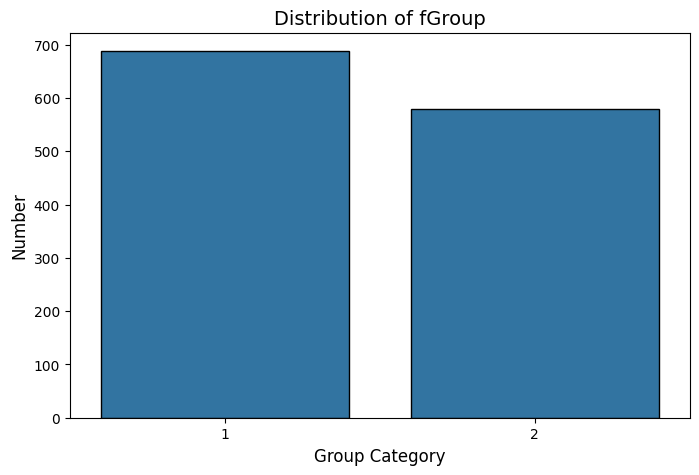

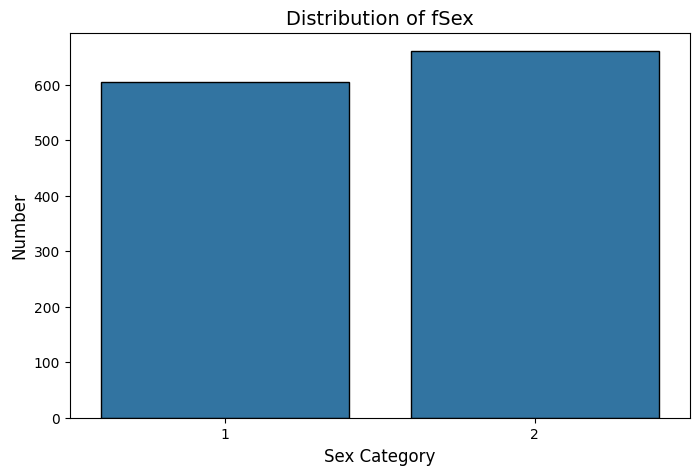

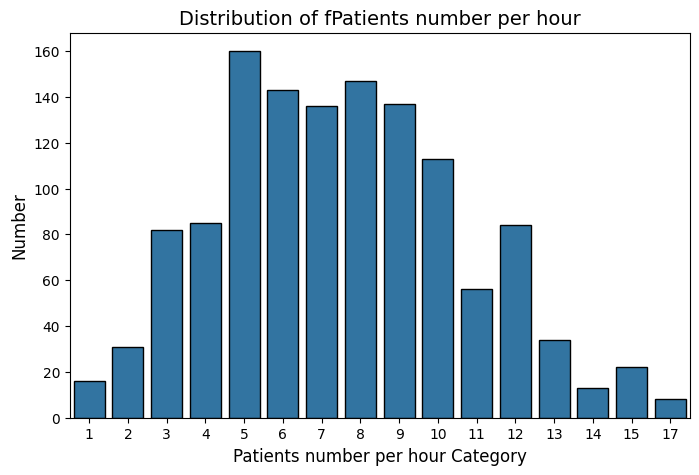

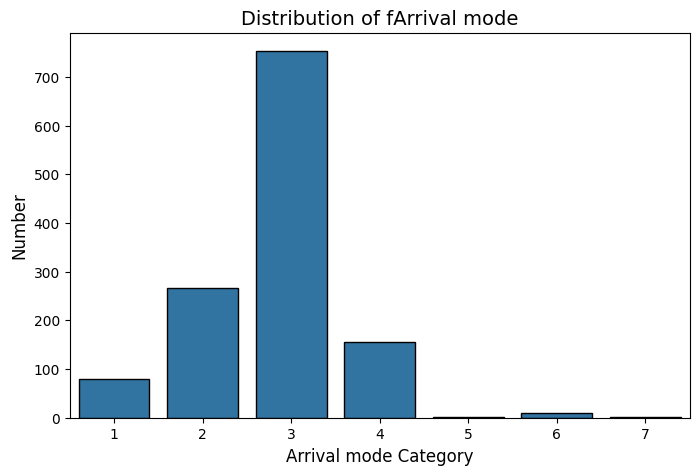

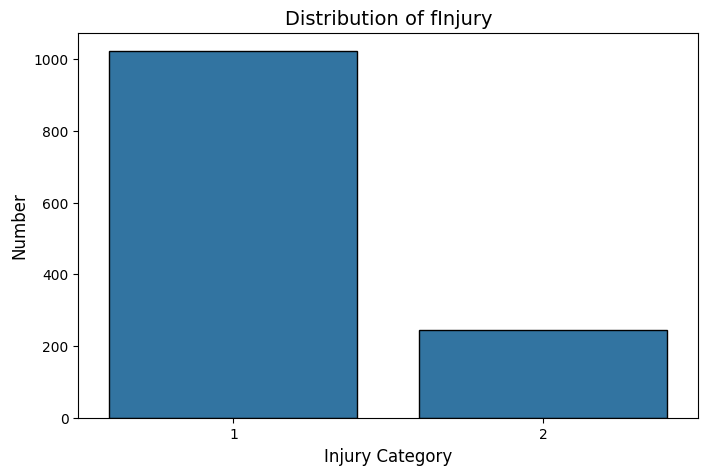

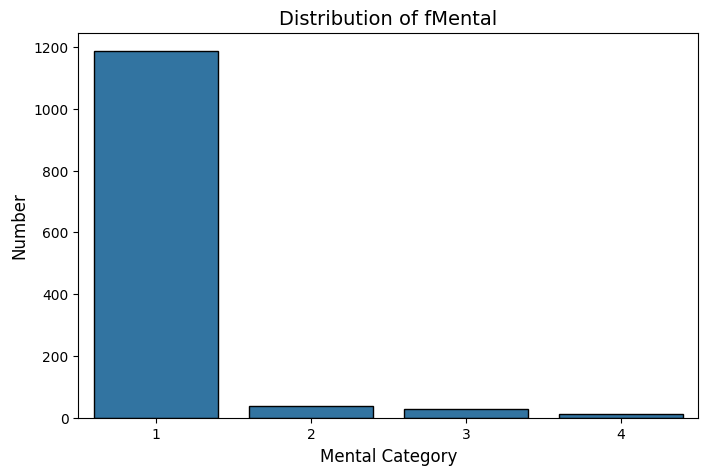

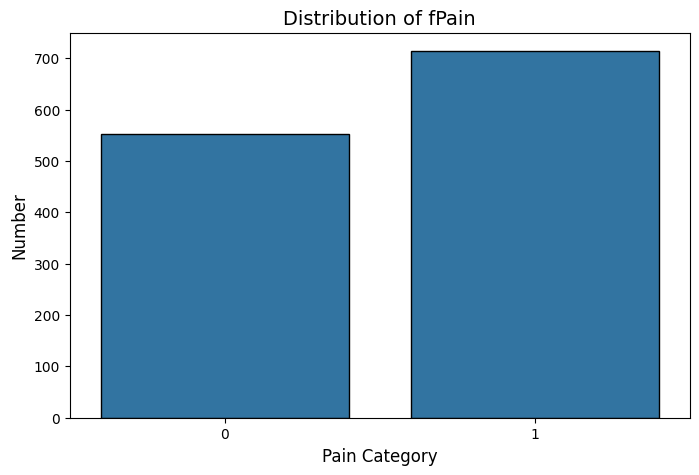

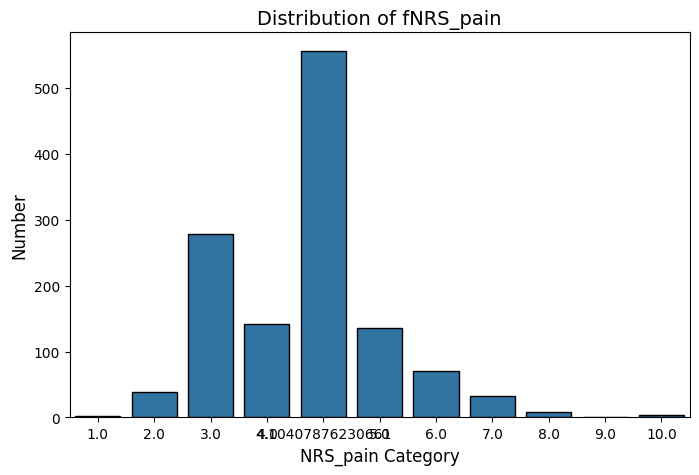

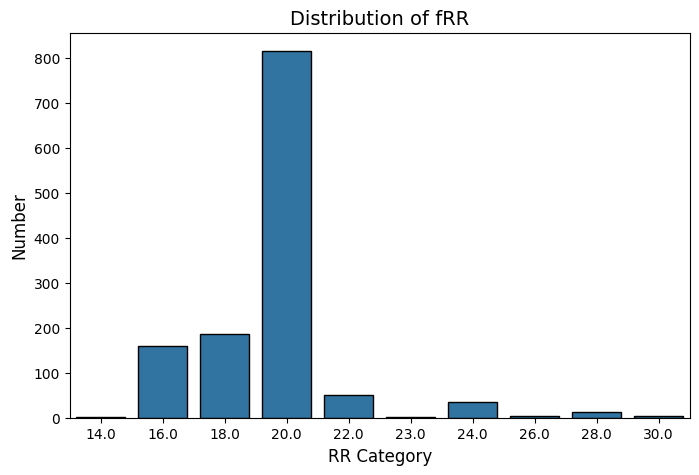

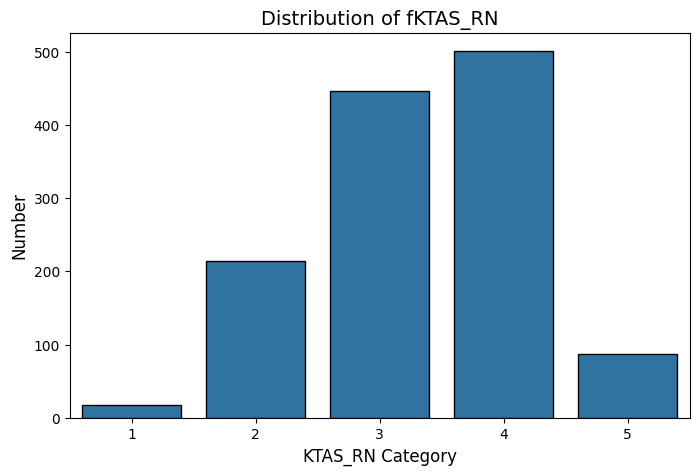

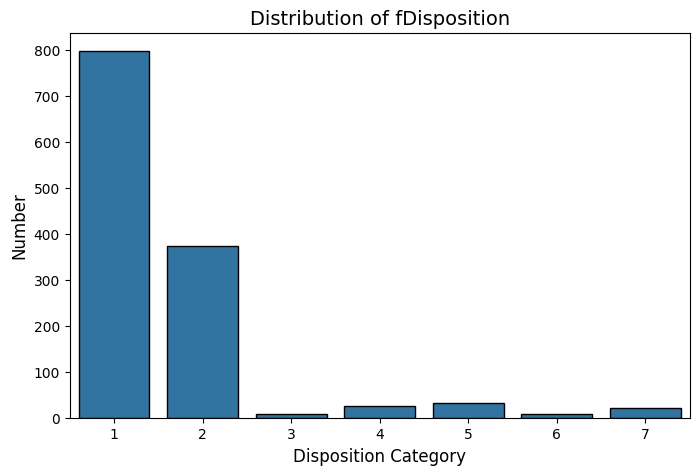

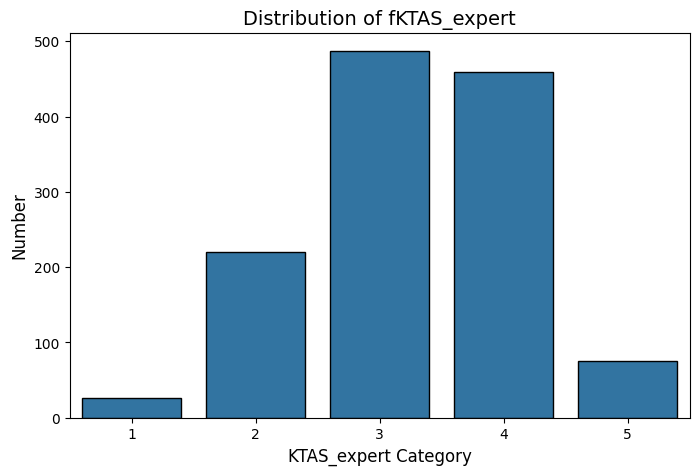

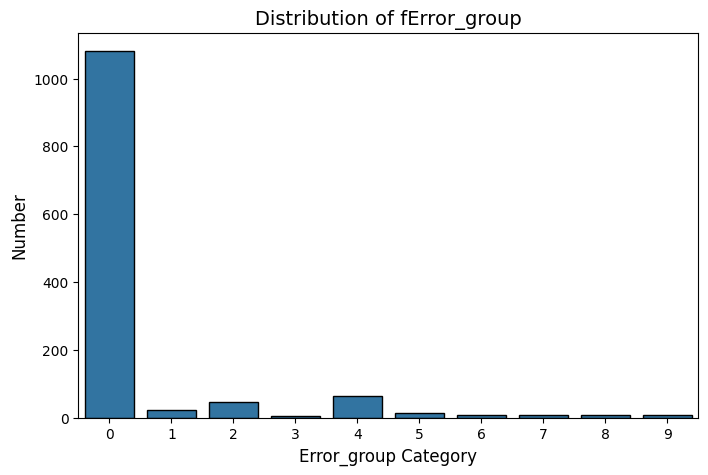

In [176]:
for feature in discreate_feature:  # using a for loop print a each feature graph
    plt.figure(figsize=(8,5))  # figure size
    sns.countplot(data=df_Emergency_join, x=feature, edgecolor="black")  # univariate analysis of each feature 
    plt.title(f"Distribution of f{feature}",fontsize=14)  
    plt.xlabel(f"{feature} Category", fontsize=12)
    plt.ylabel("Number", fontsize=12)
    plt.show()

# Bivariate analysis with dicreate features

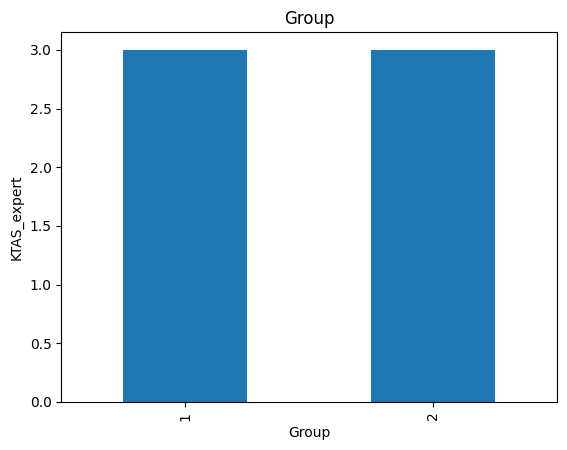

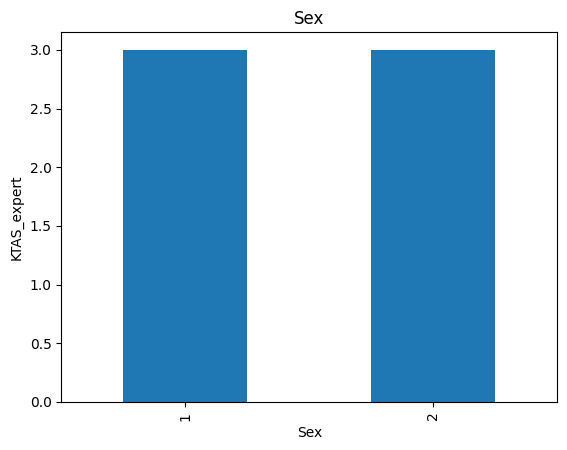

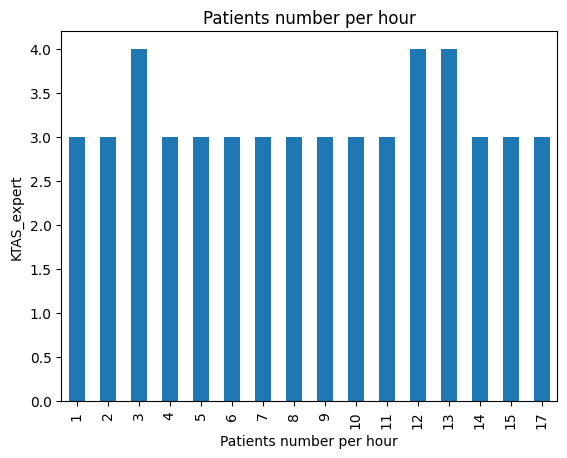

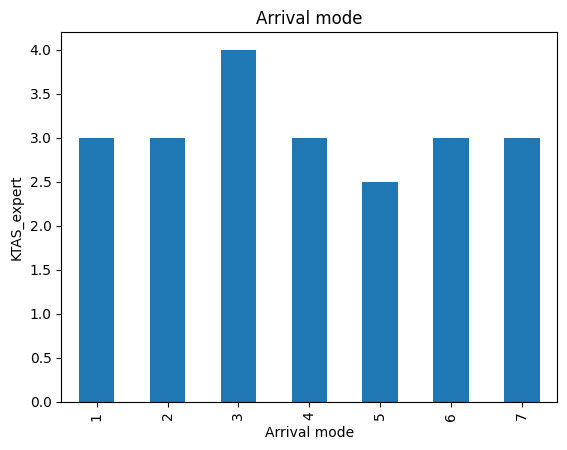

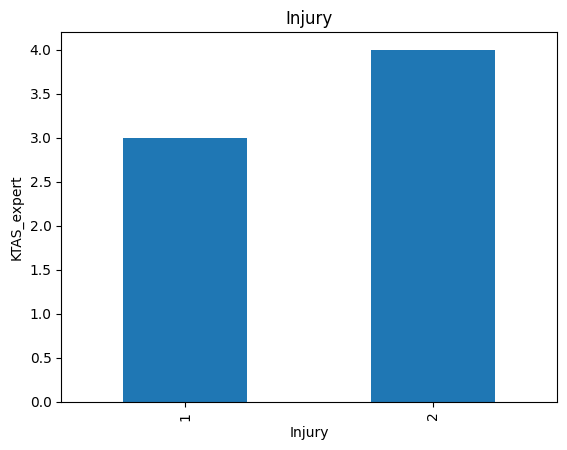

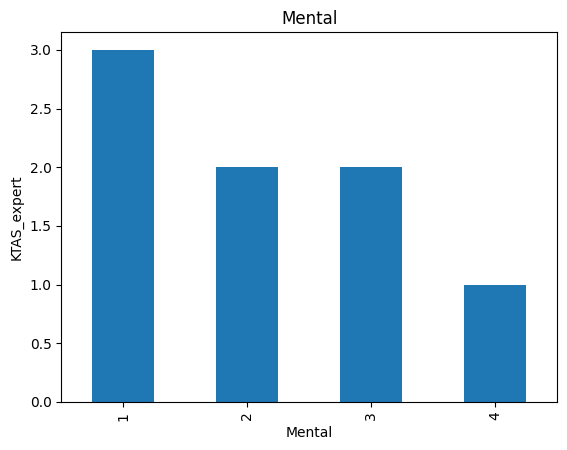

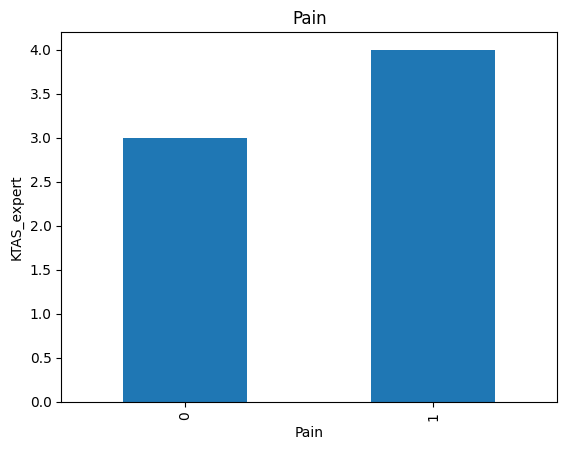

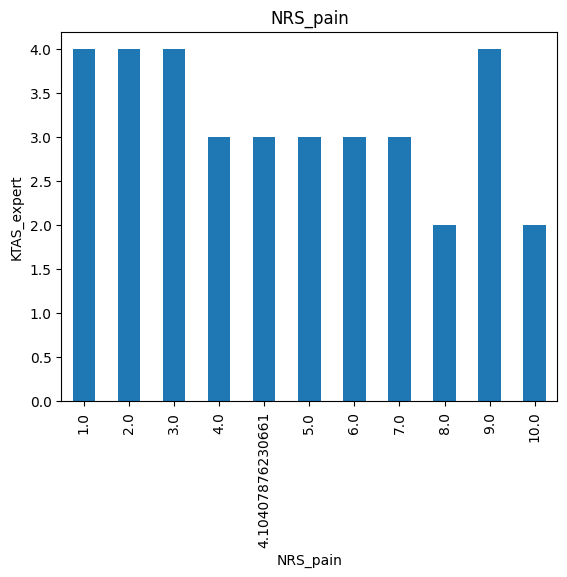

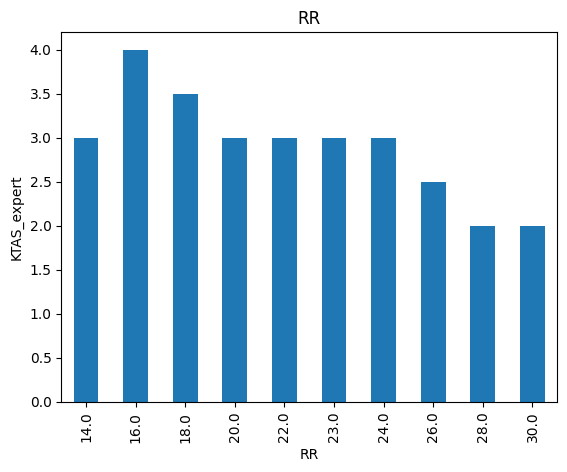

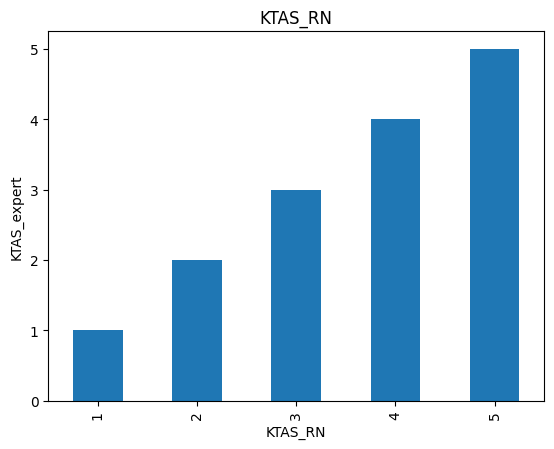

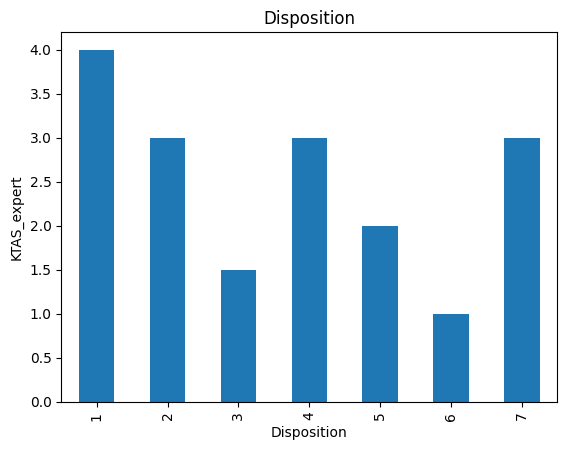

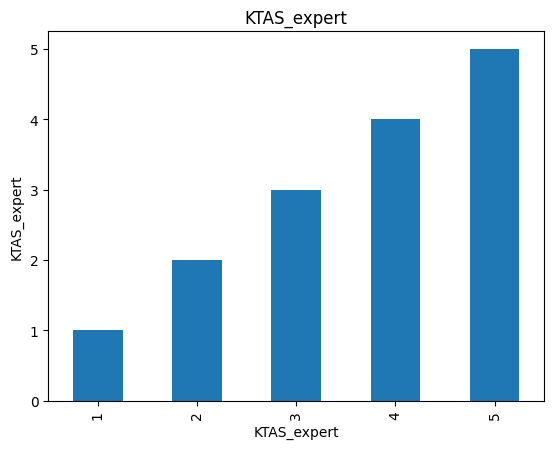

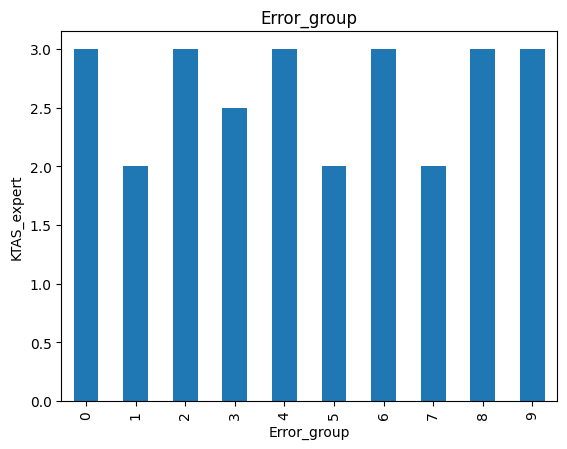

In [177]:
for feature in discreate_feature:
    data= df_Emergency_join.copy()
    data.groupby(feature)["KTAS_expert"].median().plot.bar()   # each discreate feature and target variable ktas_expert comparison
    plt.xlabel(feature)
    plt.ylabel("KTAS_expert")
    plt.title(feature)
    plt.show()

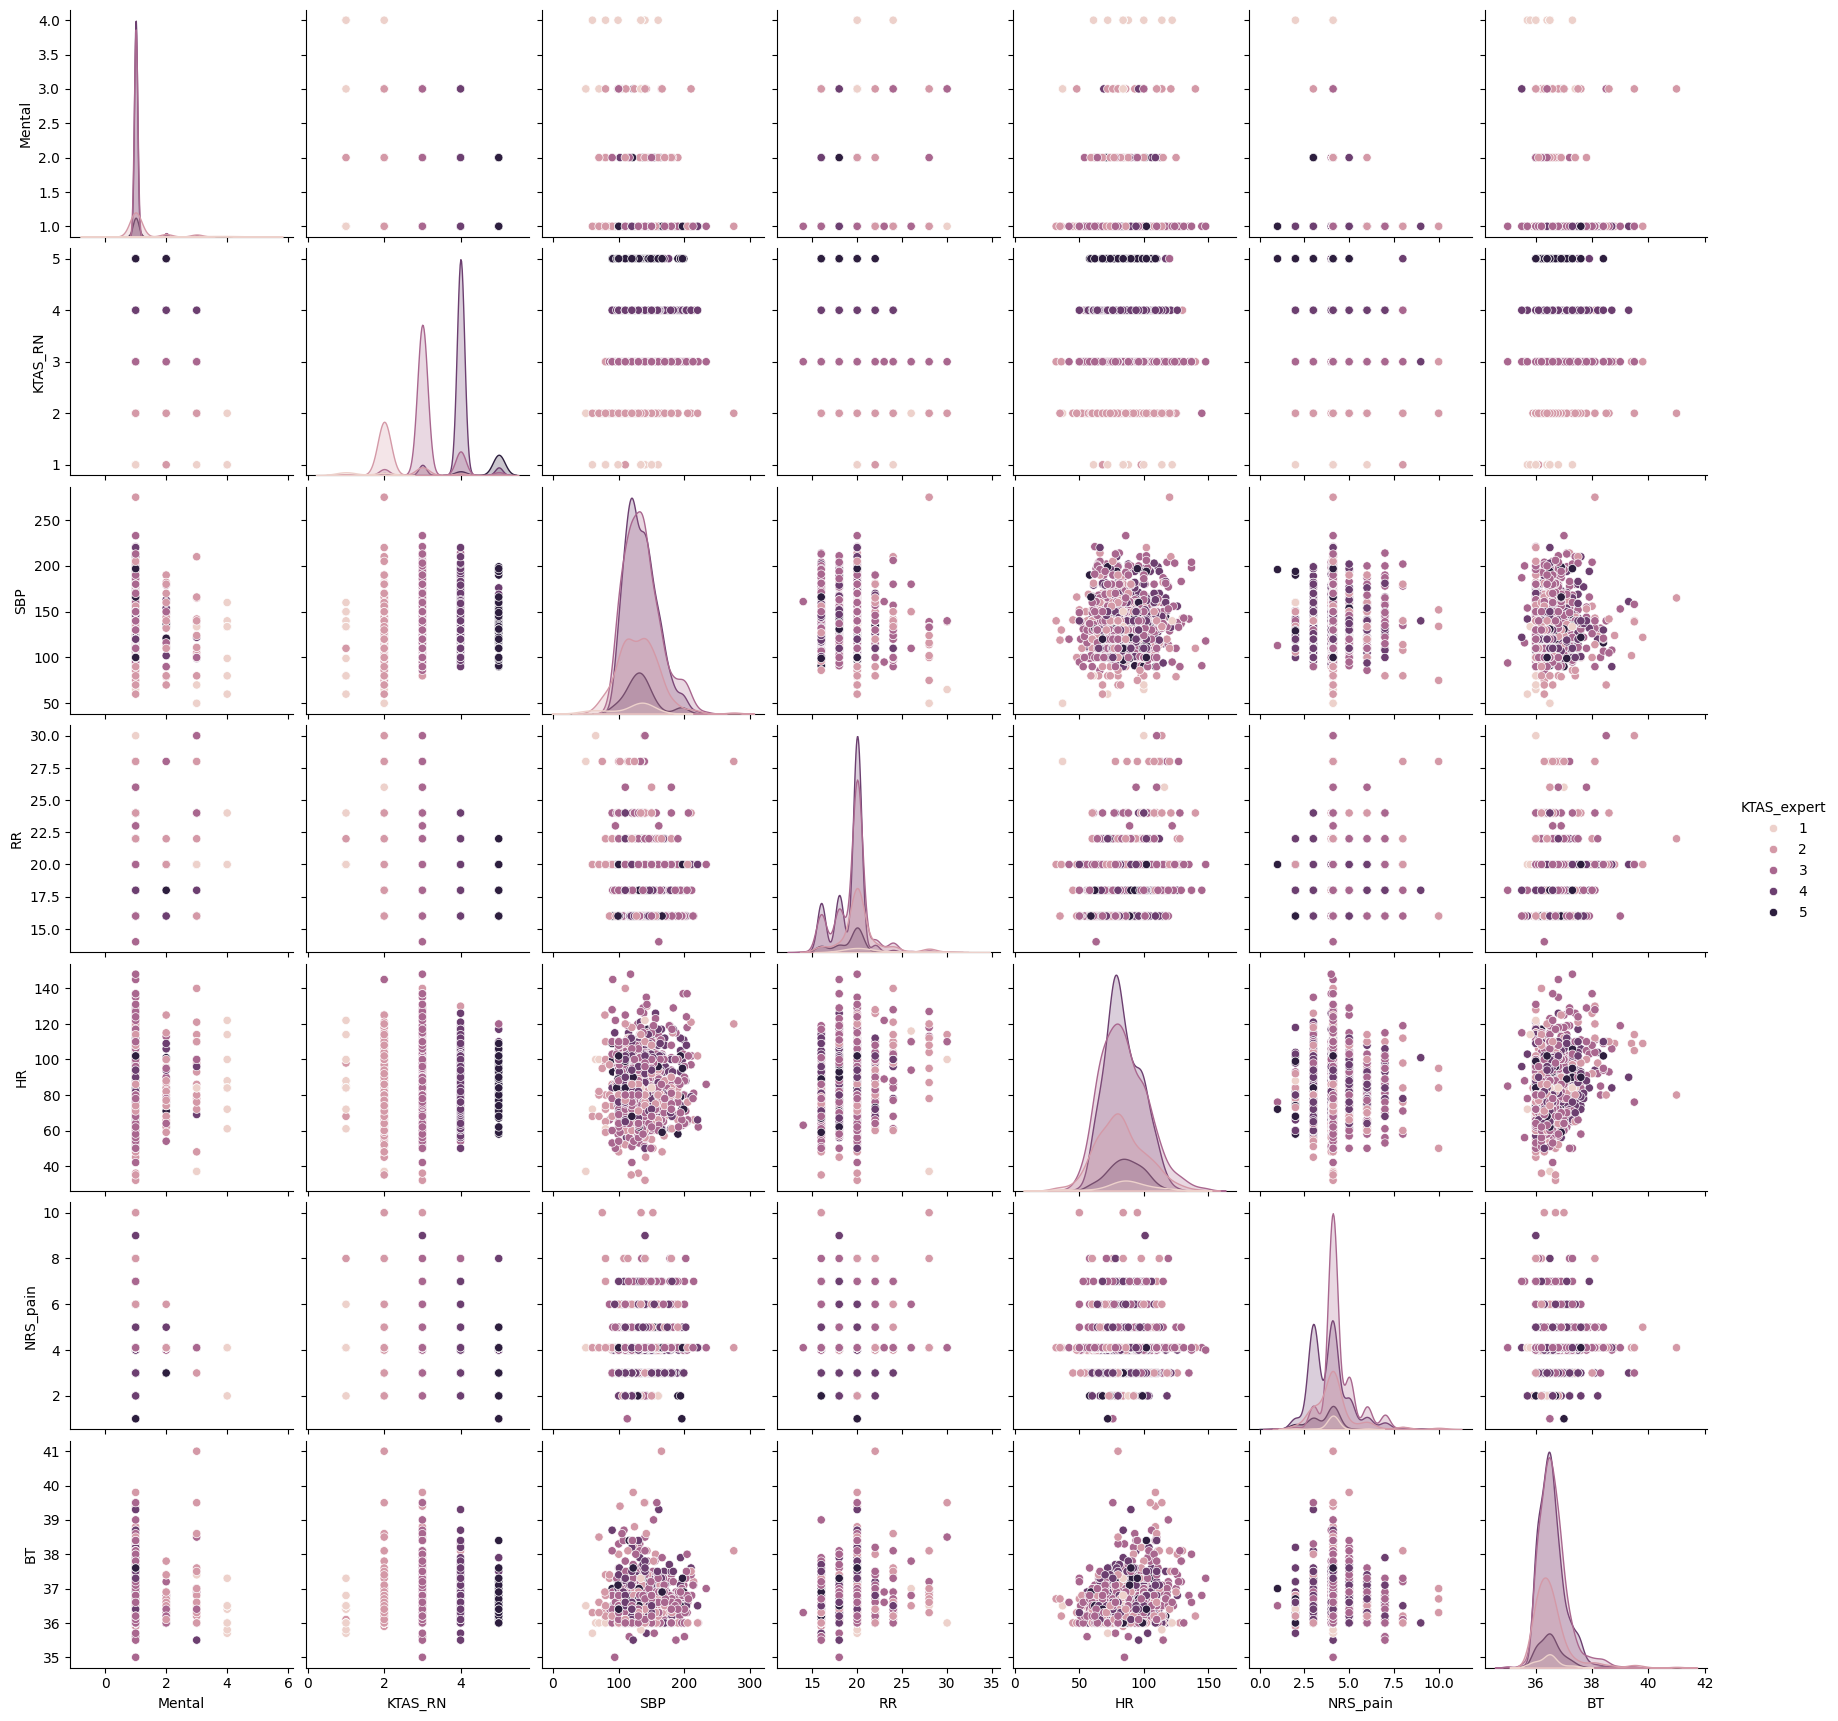

In [178]:
sns.pairplot(df_Emergency[['Mental','KTAS_RN','SBP','RR','HR','NRS_pain','BT','KTAS_expert']], hue="KTAS_expert")   # Pairplot of those 8 feature with target variable

In [179]:
## Bivariate analysis with continous features

In [180]:
continous_feature = [feature for feature in numeric_feature if len(df_Emergency_join[feature].unique())>25]  # which feature has more than 25 unique value consider as continous feature
continous_feature 

['Age', 'SBP', 'DBP', 'HR', 'BT', 'Length of stay_min', 'KTAS duration_min']

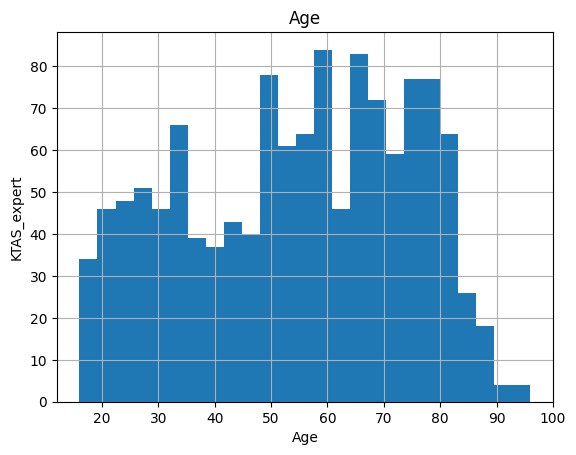

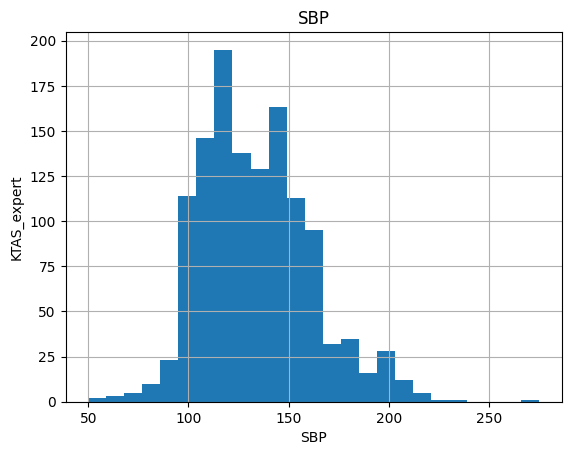

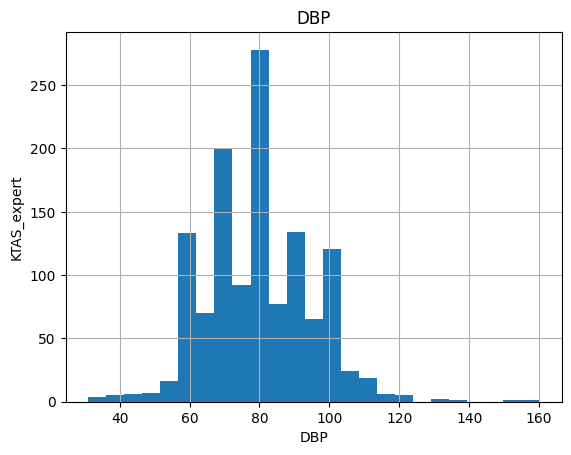

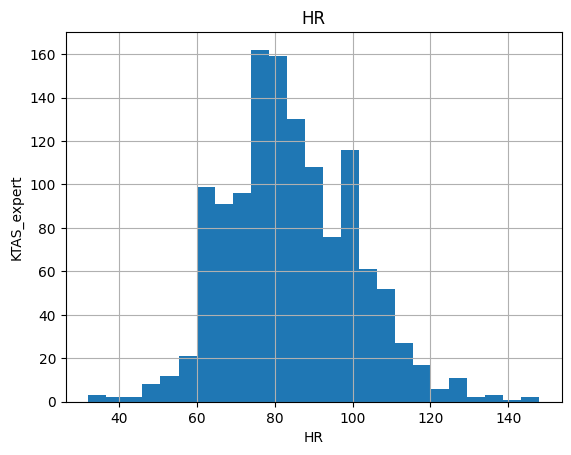

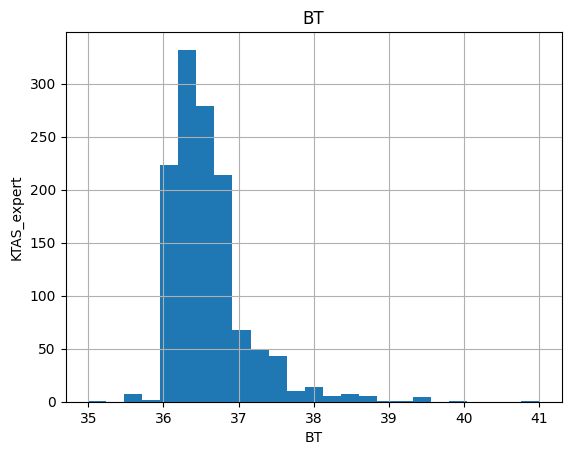

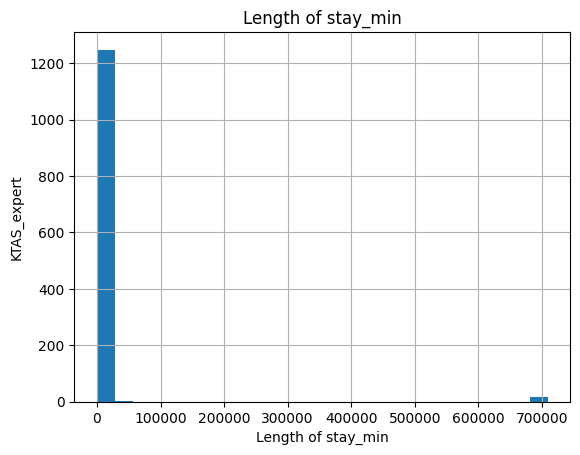

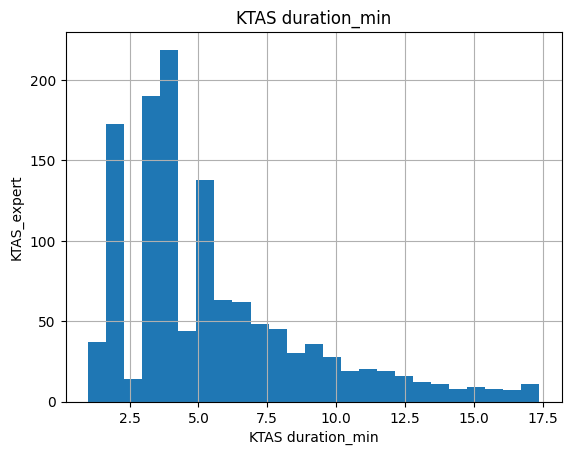

In [181]:


for feature in continous_feature:
    data= df_Emergency_join.copy()
    data[feature].hist(bins=25)       # plot a histograph for data distribution
    plt.xlabel(feature)
    plt.ylabel("KTAS_expert")
    plt.title(feature)
    plt.show()

In [182]:
# for feature in continous_feature:
#     plt.scatter(data[feature] ,data["KTAS_expert"])  # scatter plot for feature and with target variable
#     plt.xlabel(feature)
#     plt.ylabel("KTAS_expert")
#     plt.title(feature)
#     plt.show()

In [183]:
df_Emergency_join['Length of stay_min'].dtypes

dtype('int64')

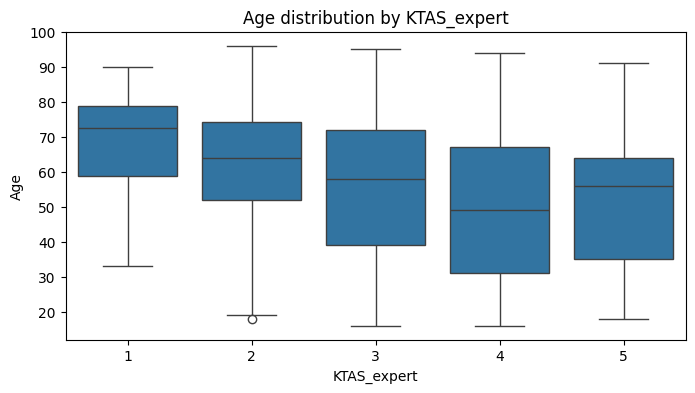

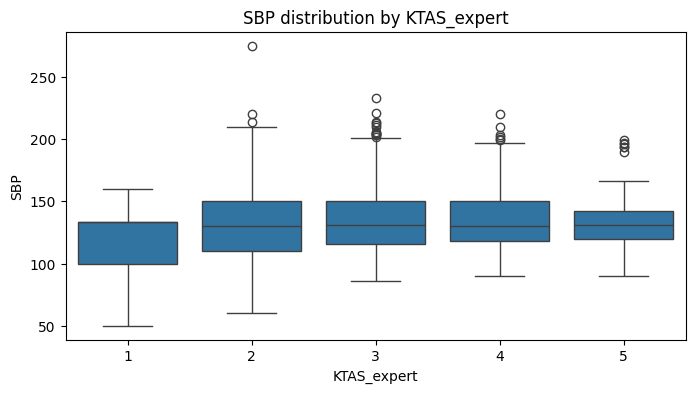

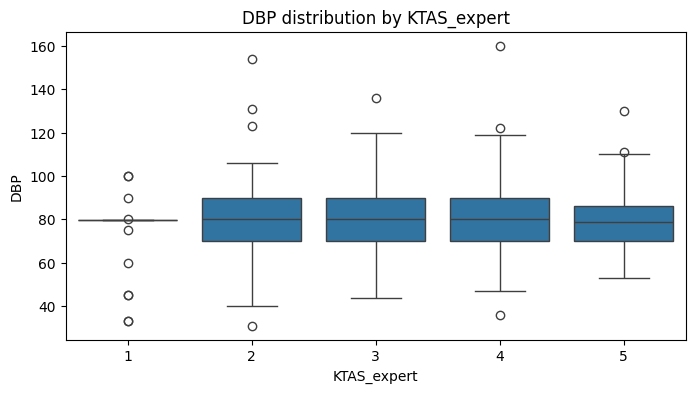

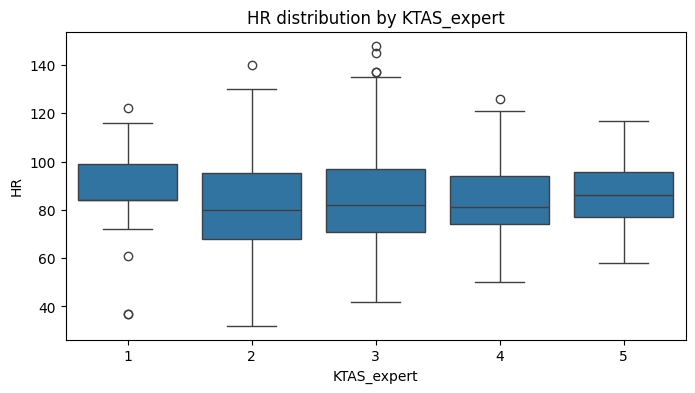

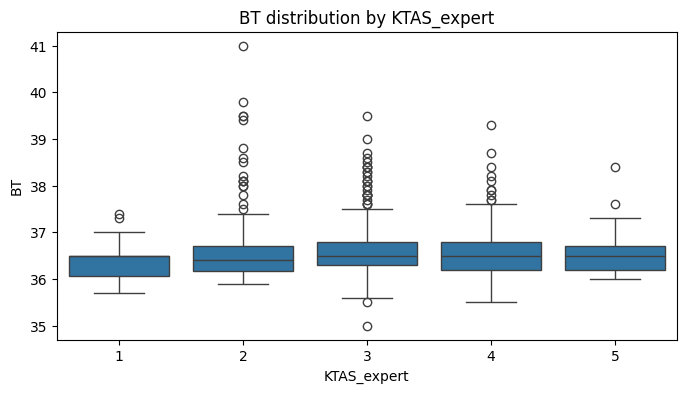

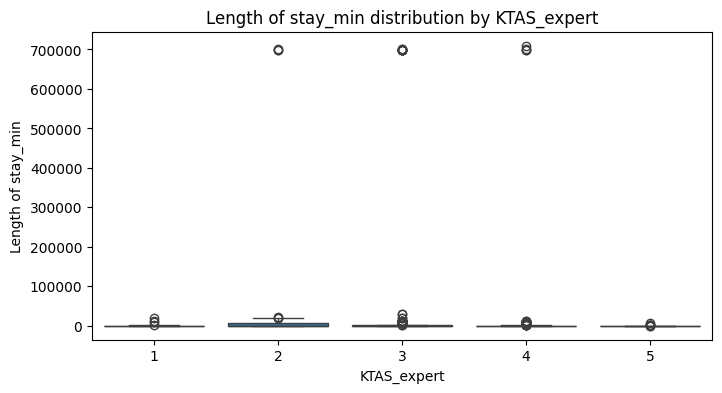

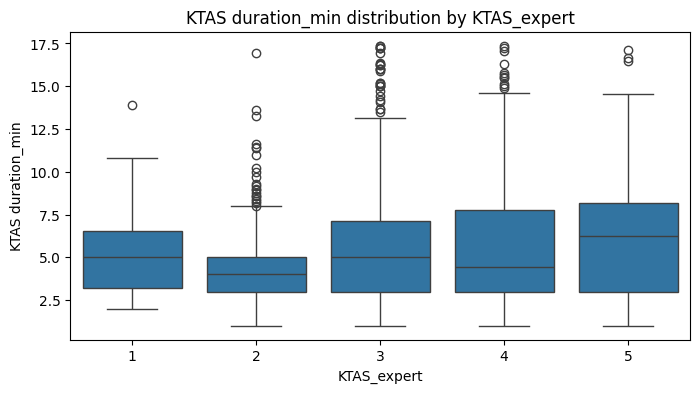

In [184]:

for feature in continous_feature:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='KTAS_expert', y=feature, data=df_Emergency_join)  # boxplot , continous_feature with ktas expert
    plt.title(f"{feature} distribution by KTAS_expert")
    plt.xlabel("KTAS_expert")
    plt.ylabel(feature)
    plt.show()

In [185]:
df_Emergency_join["Saturation"].isnull().sum()   # Now we are dropping the columns but we also check the model accuarcy with filling a missing value.If we found a relation with target so we keep it 

np.int64(697)

In [186]:
import plotly.io as pio
pio.renderers.default = "notebook"

In [187]:
fig = px.scatter(df_Emergency_join, x="SBP", y="Age", color="KTAS_expert")
#fig.show()

In [188]:
# fig = px.scatter(df_Emergency_join, x="BT", y="HR", color="KTAS_expert")
# fig.show()

In [189]:
# fig = px.scatter(df_Emergency_join, x="Mental", y="HR", color="KTAS_expert")
# fig.show()

In [190]:
# fig = px.scatter(df_Emergency_join, x="HR", y="NRS_pain", color="KTAS_expert")
# fig.show()

In [191]:
#df_Emergency_join.drop(['Chief_complain','Diagnosis in ED'], axis=1, inplace=True)  # Chief_complain and 'Diagnosis in ED' feature has text data , if we want to use we need NLP

In [192]:
#corr = df_Emergency_join.corr()  # Here by default is pearson corelation 

In [193]:
#plt.figure(figsize=(12,6))  
#sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')   # using seaborn libary  plot heatmap which shows the relation with features

In [194]:
#corr1 = df_Emergency_join.corr(method='kendall')  # this is 2d corelation method
#corr1  

In [195]:
#plt.figure(figsize=(12,6))
#sns.heatmap(corr1, annot=True, cmap='coolwarm', fmt='.2f')   # heatmap for relation of variable

In [196]:
#corr2 = df_Emergency_join.corr(method='spearman')   # This is 3rd pearson corelation method
#corr2

df_Emergency_join.describe()

,Group,Sex,Age,Patients number per hour,Arrival mode,Injury,Mental,Pain,NRS_pain,SBP,DBP,HR,RR,BT,KTAS_RN,Disposition,KTAS_expert,Error_group,Length of stay_min,KTAS duration_min
count,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000,1267.000000
mean,1.456985,1.521705,54.423836,7.519337,2.820837,1.192581,1.105762,0.563536,4.104079,133.648953,79.780291,83.963111,19.515391,36.579479,3.335438,1.609313,3.265983,0.558011,11016.102605,5.497466
std,0.498343,0.499726,19.725033,3.160563,0.807904,0.394482,0.447768,0.496143,1.062910,27.004987,14.979719,16.512102,2.000089,0.541899,0.885391,1.157983,0.885803,1.571489,80446.092065,3.459470
min,1.000000,1.000000,16.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,50.000000,31.000000,32.000000,14.000000,35.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,37.000000,5.000000,2.000000,1.000000,1.000000,0.000000,3.000000,115.000000,70.000000,72.000000,18.000000,36.200000,3.000000,1.000000,3.000000,0.000000,133.000000,3.000000
50%,1.000000,2.000000,57.000000,7.000000,3.000000,1.000000,1.000000,1.000000,4.104079,130.000000,80.000000,82.000000,20.000000,36.500000,3.000000,1.000000,3.000000,0.000000,274.000000,4.280000
75%,2.000000,2.000000,71.000000,10.000000,3.000000,1.000000,1.000000,1.000000,4.104079,150.000000,90.000000,96.000000,20.000000,36.800000,4.000000,2.000000,4.000000,0.000000,606.500000,7.000000
max,2.000000,2.000000,96.000000,17.000000,7.000000,2.000000,4.000000,1.000000,10.000000,275.000000,160.000000,148.000000,30.000000,41.000000,5.000000,7.000000,5.000000,9.000000,709510.000000,17.370000


In [197]:
#plt.figure(figsize=(12,6))
#sns.heatmap(corr2, annot=True, cmap='coolwarm', fmt='.2f')

In [198]:
#  df_copy = df_Emergency[['Mental','KTAS_RN','SBP','RR','HR','NRS_pain','BT']] # Here top 8 important feature taken

In [199]:
df_Emergency_join.isnull().sum()

Group                         0
Sex                           0
Age                           0
Patients number per hour      0
Arrival mode                  0
Injury                        0
Chief_complain                0
Mental                        0
Pain                          0
NRS_pain                      0
SBP                           0
DBP                           0
HR                            0
RR                            0
BT                            0
Saturation                  697
KTAS_RN                       0
Diagnosis in ED               2
Disposition                   0
KTAS_expert                   0
Error_group                   0
Length of stay_min            0
KTAS duration_min             0
dtype: int64

In [200]:
# Cleaning the text feature  for nlp

df_Emergency_join.columns

Index(['Group', 'Sex', 'Age', 'Patients number per hour', 'Arrival mode',
       'Injury', 'Chief_complain', 'Mental', 'Pain', 'NRS_pain', 'SBP', 'DBP',
       'HR', 'RR', 'BT', 'Saturation', 'KTAS_RN', 'Diagnosis in ED',
       'Disposition', 'KTAS_expert', 'Error_group', 'Length of stay_min',
       'KTAS duration_min'],
      dtype='object')

In [201]:
df_Emergency_join["Chief_complain"].unique

<bound method Series.unique of 0                           right ocular pain
1                          right forearm burn
2                                arm pain, Lt
3                             ascites tapping
4                             distension, abd
5                                       fever
6                       With chest discomfort
7                                 pain, chest
8                         LBP - Low back pain
9                              Eczema, Eyelid
10                      acute epigastric pain
11                                  pain, leg
12                            epigastric pain
13                                   abd pain
14                                   headache
15                                   headache
16                                         ??
17                                 Open Wound
18                                   RUQ pain
19                          Gingival swelling
20                                  chin pain
21 

In [202]:
# clean the text

ps = PorterStemmer()
ls = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))

negation_words = ["not", "no", "nor", "without"] # Remove negation words from stopwords beacuse i do not have chest pain
for word in negation_words:
    stop_words.discard(word)
print("not" in stop_words)

df_Emergency_join["Chief_complain"] = df_Emergency_join["Chief_complain"].replace(
    ["??", "#BOÞ!", ""], np.nan
)

# Fill missing with empty string
df_Emergency_join["Chief_complain"] = df_Emergency_join["Chief_complain"].fillna("")

clean_text = []
def clean_text_func(text):
    text = re.sub('[^a-zA-Z]', ' ', text)
    #print(text)
    text = text.lower()
    text = text.split()
    text =[ ls.lemmatize(word) for word in text if word not in stop_words]
    text = " ".join(text)
    clean_text.append(text)
    return text


df_Emergency_join["Chief_complain_clean"] = df_Emergency_join["Chief_complain"].apply(clean_text_func)

print(df_Emergency_join[["Chief_complain", "Chief_complain_clean"]].head(25))

False
             Chief_complain    Chief_complain_clean
0         right ocular pain       right ocular pain
1        right forearm burn      right forearm burn
2              arm pain, Lt             arm pain lt
3           ascites tapping         ascites tapping
4           distension, abd          distension abd
5                     fever                   fever
6     With chest discomfort        chest discomfort
7               pain, chest              pain chest
8       LBP - Low back pain       lbp low back pain
9            Eczema, Eyelid           eczema eyelid
10    acute epigastric pain   acute epigastric pain
11                pain, leg                pain leg
12          epigastric pain         epigastric pain
13                 abd pain                abd pain
14                 headache                headache
15                 headache                headache
16                                                 
17               Open Wound              open wound
18    

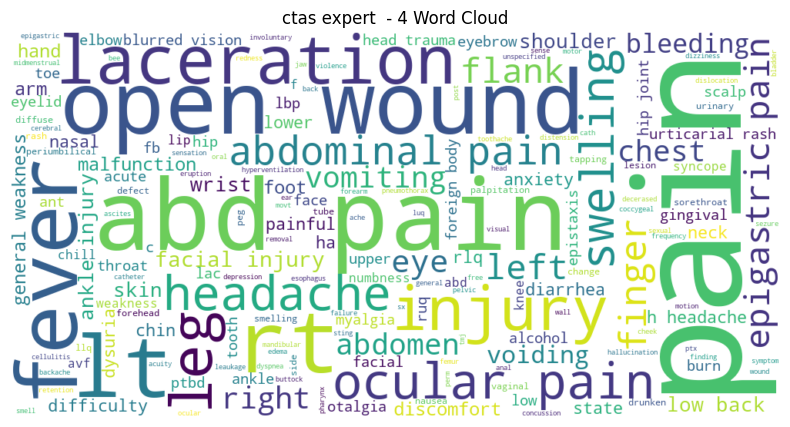

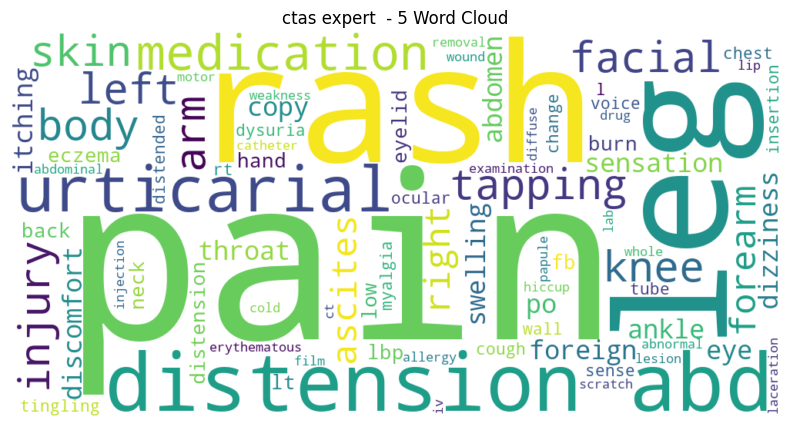

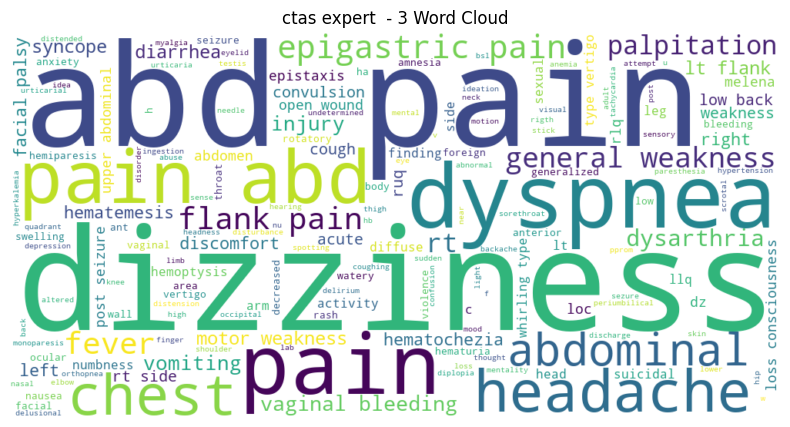

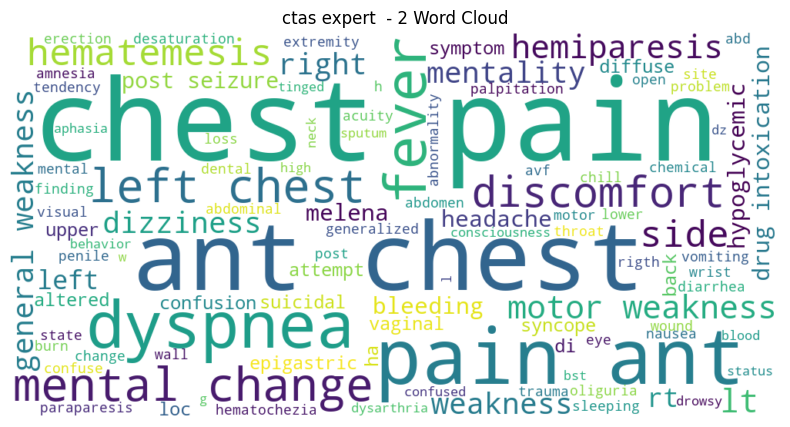

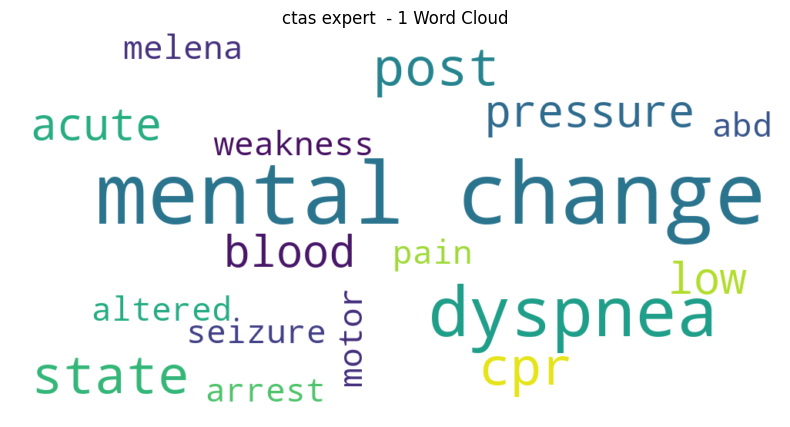

In [203]:
## word cloud for chief complain based on word
from wordcloud import WordCloud
def show_wordcloud(text_series, title):
    text = " ".join(text_series.dropna().astype(str))
    if text.strip():
        wc = WordCloud(width=1000, height=500, background_color="white").generate(text)
        plt.figure(figsize=(10,5))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(title)
        plt.show()


for KTAS_expert in df_Emergency_join["KTAS_expert"].unique():
    show_wordcloud(df_Emergency_join[df_Emergency_join["KTAS_expert"] == KTAS_expert]["Chief_complain_clean"], f"ctas expert  - {KTAS_expert} Word Cloud")



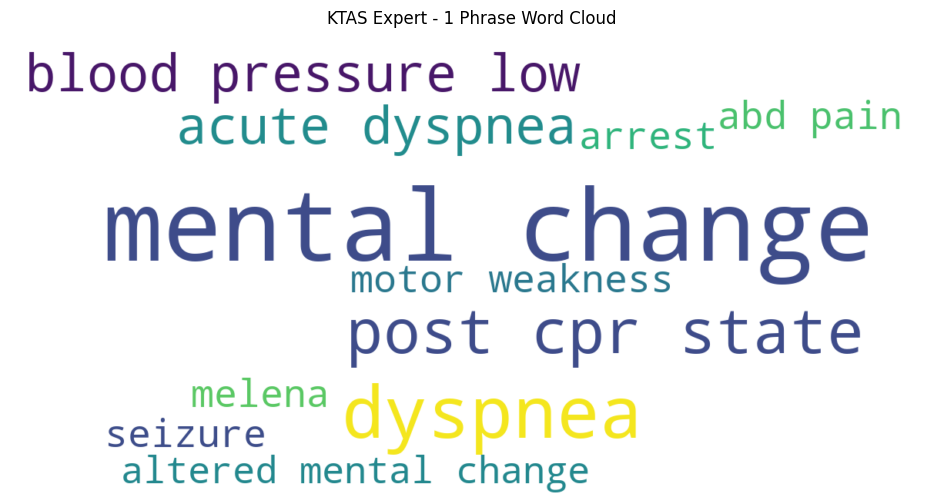

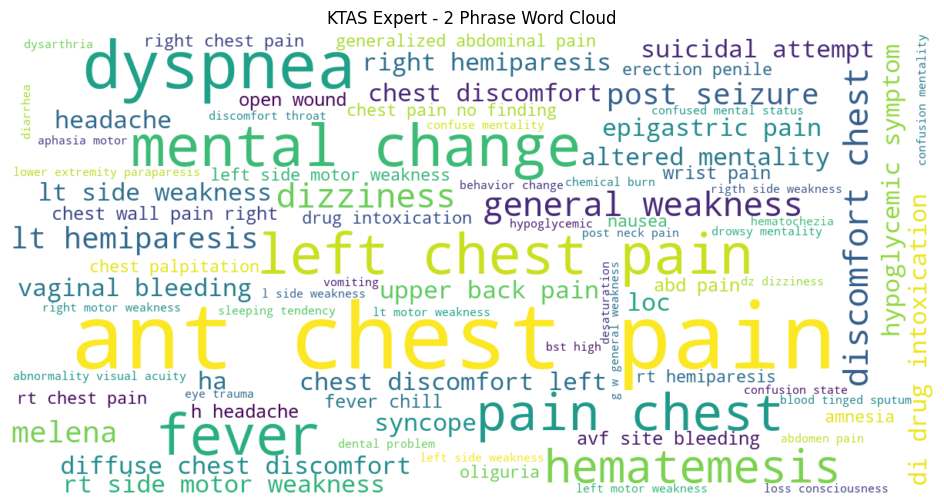

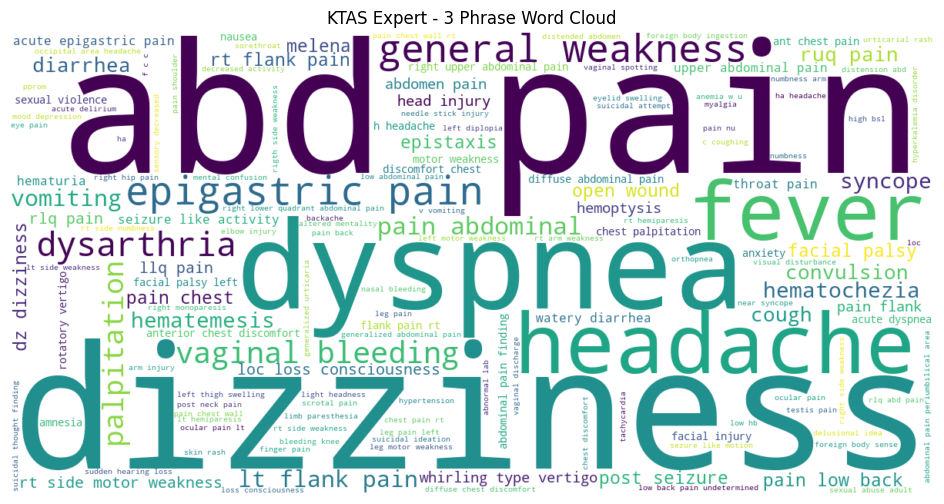

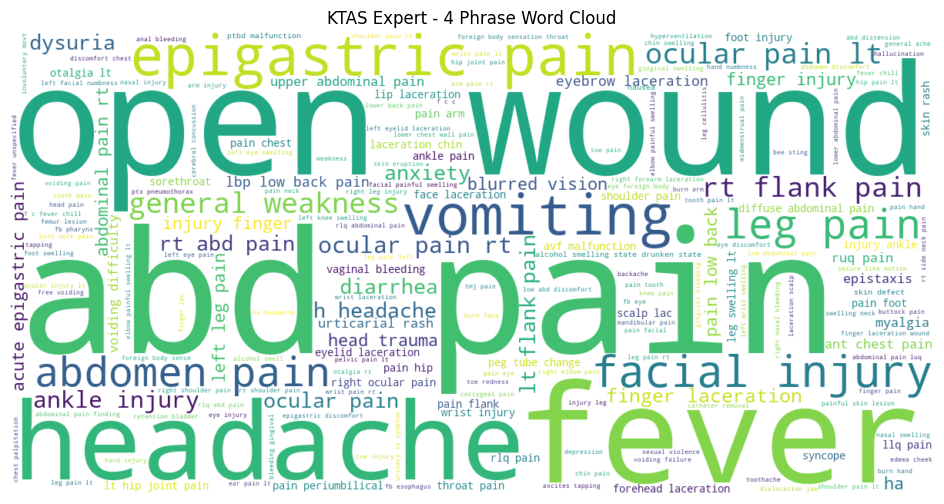

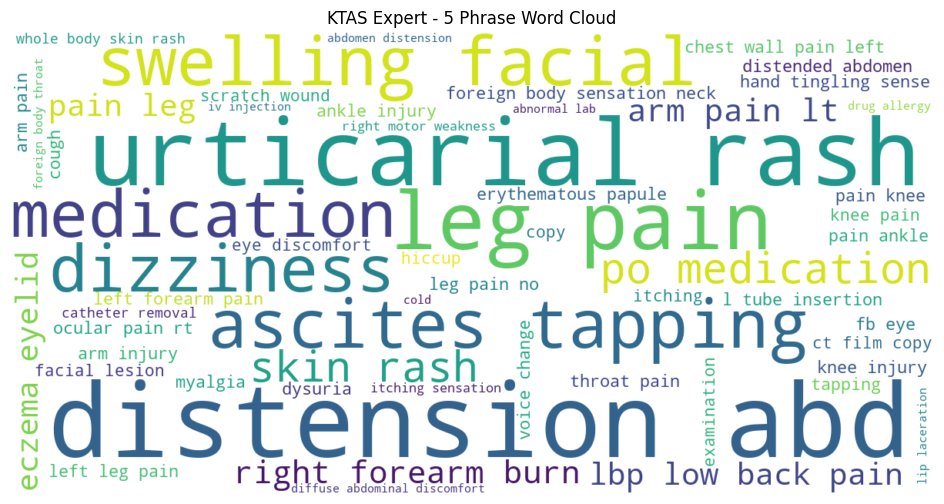

In [204]:
## word cloud for chief complain based on whole text in rows
from collections import Counter

def show_phrase_wordcloud(text_series, title):
    # Keep full phrase, not split into individual words
    phrases = text_series.dropna().astype(str).str.strip()
    phrases = phrases[phrases != ""]

    phrase_counts = Counter(phrases)

    if phrase_counts:
        wc = WordCloud(
            width=1200,
            height=600,
            background_color="white",
            collocations=False
        ).generate_from_frequencies(phrase_counts)

        plt.figure(figsize=(12, 6))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(title)
        plt.show()

for ktas in sorted(df_Emergency_join["KTAS_expert"].dropna().unique()):
    show_phrase_wordcloud(
        df_Emergency_join[df_Emergency_join["KTAS_expert"] == ktas]["Chief_complain_clean"],
        f"KTAS Expert - {ktas} Phrase Word Cloud"
    )

In [205]:
type(df_Emergency_join)
#df_Emergency_join[df_Emergency_join["KTAS_expert"] == 1]["cheif_complain_clean"]
print(len(df_Emergency_join[df_Emergency_join["KTAS_expert"] == 1]["Chief_complain_clean"]))
df_Emergency_join[df_Emergency_join["KTAS_expert"] == 1]["Chief_complain_clean"]

26


61                    dyspnea
121                   dyspnea
122        blood pressure low
123        blood pressure low
132                   dyspnea
133             acute dyspnea
150             mental change
153             mental change
155            motor weakness
161                    melena
164                   dyspnea
215             mental change
705                  abd pain
804             mental change
820             mental change
887                   seizure
968             mental change
1006           post cpr state
1009           post cpr state
1039                   arrest
1073            mental change
1078    altered mental change
1132            mental change
1143           post cpr state
1171            acute dyspnea
1192            mental change
Name: Chief_complain_clean, dtype: object

In [206]:
from collections import Counter
def top_words(text_series, top_n=15):
    all_words = " ".join(text_series.dropna().astype(str)).split()
    return Counter(all_words).most_common(top_n)

print("top words:")
print(top_words(df_Emergency_join["Chief_complain_clean"], 15))



top words:
[('pain', 414), ('chest', 102), ('abd', 99), ('dyspnea', 64), ('dizziness', 64), ('fever', 49), ('weakness', 49), ('rt', 45), ('ant', 44), ('injury', 43), ('lt', 41), ('headache', 40), ('left', 37), ('abdominal', 36), ('wound', 33)]


In [207]:
df_Emergency_join["Chief_complain_clean"].replace(" ", None).isnull().sum()
df_Emergency_join["Chief_complain_clean"].isnull().sum()

total_missing = (
    df_Emergency_join["Chief_complain_clean"].isnull() | 
    df_Emergency_join["Chief_complain_clean"].str.strip().eq("")
).sum()

print(f"Total missing values: {total_missing}")

Total missing values: 21


In [208]:
df_Emergency_join["Chief_complain_clean"] = df_Emergency_join["Chief_complain_clean"].str.strip().replace("", None)
total_missing = (
    df_Emergency_join["Chief_complain_clean"].isnull() | 
    df_Emergency_join["Chief_complain_clean"].str.strip().eq("None")
).sum()

print(f"Total missing values: {total_missing}")


Total missing values: 21


In [209]:
df_Emergency_join.dropna(subset=["Chief_complain_clean"], inplace=True)
total_missing = (
    df_Emergency_join["Chief_complain_clean"].isnull() | 
    df_Emergency_join["Chief_complain_clean"].str.strip().eq("None")
).sum()

print(f"Total missing values: {total_missing}")

df_Emergency_join.head(25)
df_Emergency_join = df_Emergency_join.reset_index(drop=True)


Total missing values: 0


In [210]:
#df_Emergency_join = df_Emergency_join.drop(index=[149,146,160])

In [211]:
df_Emergency_join.shape

(1246, 24)

In [212]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

TEXT_COL = "Chief_complain_clean"
TARGET = "KTAS_expert"
 

In [213]:
TEXT_COL = "Chief_complain_clean"
TARGET = "KTAS_expert"

NUM_COLS = [c for c in ["SBP","DBP","HR","RR","BT","NRS_pain","Age"] if c in df_Emergency_join.columns]
CAT_COLS = [c for c in ["Sex","KTAS_RN"] if c in df_Emergency_join.columns]

X = df_Emergency_join[[TEXT_COL] + NUM_COLS + CAT_COLS].copy()
y = df_Emergency_join[TARGET].copy()


In [214]:
# make sure numeric cols are numeric
for c in NUM_COLS:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [215]:
# preprocess = ColumnTransformer(
#     transformers=[
#         ("text", TfidfVectorizer(ngram_range=(1,3), min_df=2, sublinear_tf=True,
#                                   max_df=0.95, stop_words="english", max_features=5000), TEXT_COL),
#         ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
#                           ("scaler", StandardScaler())]), NUM_COLS),
#         ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
#                           ("onehot", OneHotEncoder(handle_unknown="ignore"))]), CAT_COLS)
#     ],
#     remainder="drop"
# )


In [216]:
df_Emergency_join[["SBP","DBP","HR","RR","BT","NRS_pain","Age"]].describe()

,SBP,DBP,HR,RR,BT,NRS_pain,Age
count,1246.000000,1246.000000,1246.000000,1246.000000,1246.000000,1246.000000,1246.000000
mean,133.564667,79.754292,83.945665,19.532905,36.580016,4.113826,54.434189
std,27.035108,14.971784,16.480324,1.994803,0.543004,1.065249,19.728073
min,50.000000,31.000000,32.000000,14.000000,35.000000,1.000000,16.000000
25%,114.000000,70.000000,72.000000,18.000000,36.200000,4.000000,37.000000
50%,130.000000,80.000000,82.000000,20.000000,36.500000,4.104079,57.000000
75%,150.000000,90.000000,95.000000,20.000000,36.800000,4.104079,71.000000
max,275.000000,160.000000,148.000000,30.000000,41.000000,10.000000,96.000000


In [217]:
model_results = []

# Every model result store in dataframe for record

In [218]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, f1_score

model_results = []

def evaluate_model(model_name, y_test, pred):
    
    acc = accuracy_score(y_test, pred)
    recall = recall_score(y_test, pred, average='macro')
    f1 = f1_score(y_test, pred, average='macro')

    model_results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Macro Recall": recall,
        "Macro F1": f1
    })

In [219]:
# Decision tree classifier model

In [220]:
# Random forest classifier model

In [221]:
# # recent try to find all wrong prediction on train data
# train_pred = model.predict(X_train)

# # Create dataframe to compare
# train_results = X_train.copy()
# train_results["Actual"] = y_train
# train_results["Predicted"] = train_pred
# # False negatives (very important for CTAS 1)
# fn = train_results[(train_results["Actual"] == 1) & (train_results["Predicted"] != 1)]

# print(fn)

In [222]:
# find all wrong prediction
#import pandas as pd

# results = X_test.copy()
# results["actual"] = y_test
# results["predicted"] = pred

# wrong_predictions = results[results["actual"] != results["predicted"]]

# #print(len(wrong_predictions))
# # find false negative 
# false_negative_class1 = results[(results["actual"] == 1) & (results["predicted"] != 1)]

# print(false_negative_class1)

In [223]:
# df_Emergency_join["KTAS_expert"].value_counts()
# print("Train:", model.score(X_train, y_train))
# print("Test:", model.score(X_test, y_test))

In [224]:
# cm = np.array(cm)
# for i in range(len(cm)):
#     FN = cm[i].sum() - cm[i,i]
#     print(f"Class {i+1} False Negative:", FN)

In [225]:
import tensorflow as tf


In [226]:
import numpy as np
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, GRU
from tensorflow.keras.layers import Dense, Dropout, Concatenate
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model


In [227]:
# 1) Column setup 
df = df_Emergency_join.copy()
# TEXT_COL = "Chief_complain_clean"
# TARGET   = "KTAS_expert"

# NUM_COLS = [c for c in ["SBP","DBP","HR","RR","BT","NRS_pain","Age"] if c in df.columns]
# CAT_COLS = [c for c in ["Sex","KTAS_RN"] if c in df.columns]

# print("NUM_COLS:", NUM_COLS)
# print("CAT_COLS:", CAT_COLS)

In [228]:
# 2) Fix clean text column 
# 

mapping = {
    "lbp": "low back pain",
    "lt": "left",
    "rt": "right",
    "sob": "shortness of breath",
    "cp": "chest pain",
    "n/v": "nausea vomiting",
}

def clean_text_basic(x: str) -> str:
    x = "" if pd.isna(x) else str(x)
    x = x.lower().strip()

    # Replace junk tokens you had in your notebook
    if x in ["??", "#boþ!", "?? ??? ??"]:
        x = ""

    # Expand simple abbreviations
    for k, v in mapping.items():
        x = x.replace(k, v)

    # Keep letters/numbers/spaces
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

# Ensure raw column exists
if "Chief_complain" not in df.columns and TEXT_COL not in df.columns:
    raise ValueError("Your dataframe does not contain 'Chief_complain' or 'Chief_complain_clean'")

if TEXT_COL not in df.columns:
    df[TEXT_COL] = df["Chief_complain"].apply(clean_text_basic)
else:
    # If it exists, still make sure it’s clean strings
    df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str).apply(clean_text_basic)

In [229]:

# 3) Build X/y

needed_cols = [TEXT_COL] + NUM_COLS + CAT_COLS
missing = [c for c in needed_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in df: {missing}")

X = df[needed_cols].copy()
y = df[TARGET].copy()

# Make numeric columns numeric
for c in NUM_COLS:
    X[c] = pd.to_numeric(X[c], errors="coerce")

# Drop rows with missing target
mask = ~pd.isna(y)
X = X.loc[mask].copy()
y = y.loc[mask].copy()



In [230]:
# 4) Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


In [231]:
# 5) Encode target to 0..K-1
# ----------------------------
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train.astype("str"))
y_test_enc  = le.transform(y_test.astype("str"))
num_classes = len(le.classes_)

print("Classes:", list(le.classes_), "num_classes:", num_classes)


Classes: ['1', '2', '3', '4', '5'] num_classes: 5


In [232]:
# ============================================================
# 6) TEXT → ClinicalBERT Tokenizer
# ============================================================
from transformers import AutoTokenizer

BERT_MODEL  = "emilyalsentzer/Bio_ClinicalBERT"
MAX_LEN     = 64   # chief complaints are short — 64 is enough

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

def encode_texts(texts, tokenizer, max_len):
    """
    Returns input_ids and attention_mask as numpy arrays
    """
    encoded = tokenizer(
        list(texts),
        max_length    = max_len,
        padding       = "max_length",
        truncation    = True,
        return_tensors= "np"
    )
    return encoded["input_ids"], encoded["attention_mask"]

# Encode train and test text
train_texts = X_train[TEXT_COL].fillna("").astype(str).tolist()
test_texts  = X_test[TEXT_COL].fillna("").astype(str).tolist()

X_train_ids,  X_train_mask = encode_texts(train_texts, bert_tokenizer, MAX_LEN)
X_test_ids,   X_test_mask  = encode_texts(test_texts,  bert_tokenizer, MAX_LEN)

print("input_ids shape  :", X_train_ids.shape)    # (n, 64)
print("attention_mask   :", X_train_mask.shape)   # (n, 64)

input_ids shape  : (996, 64)
attention_mask   : (996, 64)


In [233]:

# 7) TABULAR -> impute + scale + onehot

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

tabular_preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, NUM_COLS),
        ("cat", cat_pipe, CAT_COLS),
    ],
    remainder="drop"
)

X_train_tab = tabular_preprocess.fit_transform(X_train)
X_test_tab  = tabular_preprocess.transform(X_test)

# Convert to dense if sparse
if hasattr(X_train_tab, "toarray"):
    X_train_tab = X_train_tab.toarray()
    X_test_tab  = X_test_tab.toarray()

tab_dim = X_train_tab.shape[1]
print("Tabular feature dim:", tab_dim)

Tabular feature dim: 14


In [234]:

# 8) Class weights (helps rare KTAS classes)

from collections import Counter
counts = Counter(y_train_enc)
total = len(y_train_enc)
class_weight = {
    0: 10,   # KTAS 1 → Immediate (life threatening) 
    1: 3,   # KTAS 2 → Emergency (very urgent)      
    2: 2,   # KTAS 3 → Urgent                       
    3: 1,   # KTAS 4 → Less urgent                  
    4: 3,   # KTAS 5 → Non-urgent                   
}
print("class_weight:", class_weight)


class_weight: {0: 10, 1: 3, 2: 2, 3: 1, 4: 3}


In [239]:
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(DEVICE)

# --------------------------------------------------
# 1) Train/validation split
# --------------------------------------------------
X_tr_ids, X_val_ids, X_tr_mask, X_val_mask, X_tr_tab, X_val_tab, y_tr, y_val = train_test_split(
    X_train_ids,
    X_train_mask,
    X_train_tab,
    y_train_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_train_enc
)

# --------------------------------------------------
# 2) Convert to torch tensors
# --------------------------------------------------
X_tr_ids  = torch.tensor(X_tr_ids, dtype=torch.long)
X_val_ids = torch.tensor(X_val_ids, dtype=torch.long)

X_tr_mask  = torch.tensor(X_tr_mask, dtype=torch.long)
X_val_mask = torch.tensor(X_val_mask, dtype=torch.long)

X_tr_tab  = torch.tensor(X_tr_tab, dtype=torch.float32)
X_val_tab = torch.tensor(X_val_tab, dtype=torch.float32)

y_tr  = torch.tensor(y_tr, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)

train_ds = TensorDataset(X_tr_ids, X_tr_mask, X_tr_tab, y_tr)
val_ds   = TensorDataset(X_val_ids, X_val_mask, X_val_tab, y_val)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)

# --------------------------------------------------
# 3) Class weights
# --------------------------------------------------
classes = np.unique(y_train_enc)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_enc)
class_weights_t = torch.tensor(cw, dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights_t)

# --------------------------------------------------
# 4) Helpers
# --------------------------------------------------
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for input_ids, attention_mask, tabular_data, labels in loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        tabular_data = tabular_data.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, tabular_data)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for input_ids, attention_mask, tabular_data, labels in loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        tabular_data = tabular_data.to(device)
        labels = labels.to(device)

        logits = model(input_ids, attention_mask, tabular_data)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def freeze_all_bert(model):
    for p in model.bert.parameters():
        p.requires_grad = False


def unfreeze_last_n_bert_layers(model, n=4):
    # first freeze everything
    for p in model.bert.parameters():
        p.requires_grad = False

    # then unfreeze last n transformer blocks
    if hasattr(model.bert, "encoder"):  # BERT / RoBERTa style
        for layer in model.bert.encoder.layer[-n:]:
            for p in layer.parameters():
                p.requires_grad = True

    elif hasattr(model.bert, "transformer"):  # DistilBERT style
        for layer in model.bert.transformer.layer[-n:]:
            for p in layer.parameters():
                p.requires_grad = True

    # keep custom heads trainable
    for name, p in model.named_parameters():
        if "text_head" in name or "tab_branch" in name or "fusion" in name:
            p.requires_grad = True


def run_training(model, train_loader, val_loader, optimizer, scheduler, criterion, device, epochs=5, patience=4):
    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    wait = 0

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)
    return history

# --------------------------------------------------
# 5) Phase 1: freeze BERT, train heads
# --------------------------------------------------
print("=" * 50)
print("Phase 1: Training with BERT frozen")
print("=" * 50)

freeze_all_bert(model)

# ensure heads are trainable
for name, p in model.named_parameters():
    if "text_head" in name or "tab_branch" in name or "fusion" in name:
        p.requires_grad = True

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=2, factor=0.5)

history_phase1 = run_training(
    model, train_loader, val_loader,
    optimizer, scheduler, criterion, DEVICE,
    epochs=3, patience=4
)

# --------------------------------------------------
# 6) Phase 2: unfreeze last 4 BERT layers
# --------------------------------------------------
print("\n" + "=" * 50)
print("Phase 2: Fine-tuning last 4 BERT layers")
print("=" * 50)

unfreeze_last_n_bert_layers(model, n=4)

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-6)
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=2, factor=0.5)

history_phase2 = run_training(
    model, train_loader, val_loader,
    optimizer, scheduler, criterion, DEVICE,
    epochs=15, patience=4
)

Phase 1: Training with BERT frozen
Epoch 1/3 | Train Loss: 1.5689 | Train Acc: 0.4171 | Val Loss: 1.4969 | Val Acc: 0.6250
Epoch 2/3 | Train Loss: 1.4706 | Train Acc: 0.5025 | Val Loss: 1.4091 | Val Acc: 0.6300
Epoch 3/3 | Train Loss: 1.3712 | Train Acc: 0.6181 | Val Loss: 1.3130 | Val Acc: 0.6950

Phase 2: Fine-tuning last 4 BERT layers
Epoch 1/15 | Train Loss: 1.3164 | Train Acc: 0.6420 | Val Loss: 1.2896 | Val Acc: 0.6950
Epoch 2/15 | Train Loss: 1.3082 | Train Acc: 0.6407 | Val Loss: 1.2606 | Val Acc: 0.7400
Epoch 3/15 | Train Loss: 1.3013 | Train Acc: 0.6570 | Val Loss: 1.2472 | Val Acc: 0.7450
Epoch 4/15 | Train Loss: 1.2758 | Train Acc: 0.6457 | Val Loss: 1.2297 | Val Acc: 0.7350
Epoch 5/15 | Train Loss: 1.2498 | Train Acc: 0.6683 | Val Loss: 1.2144 | Val Acc: 0.7400
Epoch 6/15 | Train Loss: 1.2483 | Train Acc: 0.6809 | Val Loss: 1.2039 | Val Acc: 0.7550
Epoch 7/15 | Train Loss: 1.2318 | Train Acc: 0.6658 | Val Loss: 1.1828 | Val Acc: 0.7200
Epoch 8/15 | Train Loss: 1.2131 | Tra

In [240]:

# 10) Train — Two Phase Strategy


callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", patience=2, factor=0.5, min_lr=1e-7
    ),
]

# ── Phase 1: Train with BERT frozen (fast, gets fusion right) ─
print("=" * 50)
print("Phase 1: Training with BERT frozen (3 epochs)")
print("=" * 50)

history_phase1 = model.fit(
    x = {
        "input_ids"     : X_train_ids,
        "attention_mask": X_train_mask,
        "tabular_input" : X_train_tab
    },
    y                = y_train_enc,
    validation_split = 0.20,
    epochs           = 3,          # ← just warm up the head
    batch_size       = 16,         # ← small batch for BERT memory
    class_weight     = class_weight,
    verbose          = 1
)

# ── Phase 2: Unfreeze last 4 BERT layers and fine-tune ────────
print("\n" + "=" * 50)
print("Phase 2: Fine-tuning last 4 BERT layers")
print("=" * 50)

for layer in bert_backbone.layers[-4:]:
    layer.trainable = True

# Recompile with much smaller LR for fine-tuning
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=5e-6),  # ← very small
    loss      = "sparse_categorical_crossentropy",
    metrics   = ["accuracy"]
)

history_phase2 = model.fit(
    x = {
        "input_ids"     : X_train_ids,
        "attention_mask": X_train_mask,
        "tabular_input" : X_train_tab
    },
    y                = y_train_enc,
    validation_split = 0.20,
    epochs           = 15,
    batch_size       = 16,
    callbacks        = callbacks,
    class_weight     = class_weight,
    verbose          = 1
)

Phase 1: Training with BERT frozen (3 epochs)


AttributeError: 'ClinicalBERTFusionModel' object has no attribute 'fit'

In [241]:

# 11) Evaluate

probs = model.predict(
    {
        "input_ids"     : X_test_ids,
        "attention_mask": X_test_mask,
        "tabular_input" : X_test_tab
    },
    verbose=0
)

y_pred_enc = probs.argmax(axis=1)

# Optional threshold guard (keep from before)
def predict_with_threshold(probs, t1=0.20, t2=0.15):
    y_pred = []
    for prob in probs:
        base = np.argmax(prob)
        if base in [3, 4] and prob[base] > 0.60:
            y_pred.append(base)
        elif prob[0] >= t1:
            y_pred.append(0)
        elif prob[1] >= t2:
            y_pred.append(1)
        else:
            y_pred.append(base)
    return np.array(y_pred)

y_pred_enc = predict_with_threshold(probs)

print("Accuracy:", accuracy_score(y_test_enc, y_pred_enc))
print("Confusion matrix:\n", confusion_matrix(y_test_enc, y_pred_enc))
print(classification_report(y_test_enc, y_pred_enc, target_names=le.classes_))


AttributeError: 'ClinicalBERTFusionModel' object has no attribute 'predict'